In [1]:
#Import packages
#---------------------------------------
import sys
import os
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import matplotlib
import warnings
import h5py
import seaborn as sns
warnings.filterwarnings("ignore", category=RuntimeWarning) 

#Import your modules
#---------------------------------------
import admin_functions as adfn
import CCM as cfn

# Define paths
#----------------------------------------------------------------------
Fcode = '/Users/dominicburrows/Dropbox/PhD/Analysis/my_scripts/GitHub/'
Fdata = '/Users/dominicburrows/Dropbox/PhD/analysis/Project/'
Fdoc = '/Users/dominicburrows/Documents/'
F10t = '/Volumes/Dominic 10tb/Data2process/Project/' 
F10t2 = '/Volumes/Dominic 10tb2/Data2process/Project/'
Ftm = '/Volumes/Dominic Time Machine/'
Ffig = '/Users/dominicburrows/Dropbox/PhD/figures/'

%load_ext autoreload
sys.version

'3.7.6 (default, Jan  8 2020, 13:42:34) \n[Clang 4.0.1 (tags/RELEASE_401/final)]'

In [116]:
#CAUSAL SEIZURE NETWORK CHANGES

#DUMB function for grouping mean ccm values into matrix
def ccm_mat(data_l, coord_l, mode):
    ccm_v = np.zeros((16)) #vector representation of ccm matrix

    for b in range(len(data_l)):

        ccm = cfn.ccm_stats(data_l[b], 'ccm')
        coord = np.load(coord_l[b], allow_pickle=True).item()['coord']


        #Choose granularity of cell labelling
        if mode == 'coarse':
            lab_v = coord[:,4] #coord labels - coarse 
            lab_unq = np.array(['Telencephalon', 'Diencephalon', 'Midbrain', 'Hindbrain']) #Order labels and choose major brain regions

        if mode == 'gran':
            lab_v = coord[:,3] #coord labels - granular
            lab_unq = np.unique(lab_v)


        #Initialise heatmap
        ccm_mat = np.zeros((lab_unq.shape[0], lab_unq.shape[0])) #create mean matrix to put data into
        row_v, col_v = [],[] #Vectors of row and column labels
        count=0
        #Loop over all labels
        for x,l1 in enumerate(lab_unq):
            curr_row = np.where(lab_v == l1)[0]

            for y,l2 in enumerate(lab_unq):
                curr_col = np.where(lab_v == l2)[0]

                #extend into 2 long vectors containing all cells which cover l1->l2
                #Extended row values -> repeat each element n times (n is num of column elements)
                ext_row = np.repeat(curr_row, curr_col.shape[0])

                #Extended col values -> repeat entire vector m times (m is num of row elements)
                ext_col = np.tile(curr_col, curr_row.shape[0])

                mean_ccm = np.mean(ccm[ext_row, ext_col]) #Calculate mean ccm value over all elements
                row_v, col_v = np.append(row_v,l1), np.append(col_v, l2)
                #ccm_mat[x,y] = mean_ccm
                ccm_v[count] += mean_ccm
                count+=1
        print('Done ' + str(b) + ' of ' + str(len(data_l)))

    return(ccm_v/count, row_v, col_v)

In [117]:
lab_v = coord[:,3] #coord labels - granular
lab_unq = np.unique(lab_v)
lab_unq

NameError: name 'coord' is not defined

In [317]:
lab_unq.shape

(63,)

In [118]:
#CAUSAL SEIZURE NETWORK CHANGES - COARSE

#DUMB function for grouping mean ccm values into matrix and testing significance
def ccm_mat_sig(data_l, coord_l, mode):
    ccm_mat = np.zeros((len(data_l),4, 4)) #create mean matrix to put data into

    for b in range(len(data_l)):

        ccm = cfn.ccm_stats(data_l[b], 'ccm')
        coord = np.load(coord_l[b], allow_pickle=True).item()['coord']


        #Choose granularity of cell labelling
        if mode == 'coarse':
            lab_v = coord[:,4] #coord labels - coarse 
            lab_unq = np.array(['Telencephalon', 'Diencephalon', 'Midbrain', 'Hindbrain']) #Order labels and choose major brain regions


        #Initialise heatmap
        count=0
        #Loop over all labels
        for x,l1 in enumerate(lab_unq):
            curr_row = np.where(lab_v == l1)[0]

            for y,l2 in enumerate(lab_unq):
                curr_col = np.where(lab_v == l2)[0]

                #extend into 2 long vectors containing all cells which cover l1->l2
                #Extended row values -> repeat each element n times (n is num of column elements)
                ext_row = np.repeat(curr_row, curr_col.shape[0])

                #Extended col values -> repeat entire vector m times (m is num of row elements)
                ext_col = np.tile(curr_col, curr_row.shape[0])

                mean_ccm = np.mean(ccm[ext_row, ext_col]) #Calculate mean ccm value over all elements
                ccm_mat[b,x,y] = mean_ccm
        print('Done ' + str(b) + ' of ' + str(len(data_l)))

    return(ccm_mat)

In [392]:
np.where(lab_v == lab_unq[1])[0], np.where(lab_v == lab_unq[0])[0]


(array([14914, 15014, 15030, 15098, 15100, 15152, 15200, 15210, 15217,
        15228, 15263, 15322, 15347, 15361, 15386, 15389, 15407, 15431,
        15472, 15499, 15530, 15536, 15561, 15629, 15649, 15650, 15719,
        15745, 15824, 15891, 15892, 15940, 15952, 15979, 16011, 16030,
        16079]),
 array([], dtype=int64))

In [4]:
#CAUSAL SEIZURE NETWORK CHANGES - GRAN

#DUMB function for grouping mean ccm values into matrix and testing significance
def ccm_mat_sig_gran(data_l, coord_l, mode):
    #-----------------------------------------------------------------------------------
    Fzbb = '/Users/dominicburrows/Dropbox/PhD/analysis/' + 'zbrain_stacks/'
    atlasim = Fzbb + 'atlas/pajevic1.tif'
    atlasli = Fzbb + 'atlas/Pajevic_annotations.csv'
    atlaslab=pd.read_csv(atlasli, sep=',',header=None)

    lab_unq = np.unique(np.array(atlaslab[1]))
    ccm_mat = np.zeros((len(data_l),lab_unq.shape[0], lab_unq.shape[0])) #create mean matrix to put data into

    for b in range(len(data_l)):

        ccm = cfn.ccm_stats(data_l[b], 'ccm')
        coord = np.load(coord_l[b], allow_pickle=True).item()['coord']

        lab_v = coord[:,3] #coord labels - coarse 


        #Initialise heatmap
        count=0
        #Loop over all labels
        for x,l1 in enumerate(lab_unq):
            curr_row = np.where(lab_v == l1)[0]

            for y,l2 in enumerate(lab_unq):
                curr_col = np.where(lab_v == l2)[0]
                
                if len(curr_row) ==0 or len(curr_col) == 0:
                    mean_ccm = 0
                    
                else:
                    #extend into 2 long vectors containing all cells which cover l1->l2
                    #Extended row values -> repeat each element n times (n is num of column elements)
                    ext_row = np.repeat(curr_row, curr_col.shape[0])

                    #Extended col values -> repeat entire vector m times (m is num of row elements)
                    ext_col = np.tile(curr_col, curr_row.shape[0])

                    mean_ccm = np.mean(ccm[ext_row, ext_col]) #Calculate mean ccm value over all elements
                ccm_mat[b,x,y] = mean_ccm
        print('Done ' + str(b) + ' of ' + str(len(data_l)))

    return(ccm_mat)

In [119]:
#GROUP ALL BASELINE INTO AVERAGE PLOT
mode = 'coarse'

data_bln_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + 'BLN' + '_run-01_t' + '*xmap*')
coord_bln_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  'BLN' + '_run' + '*1_pre-CCM.npy*')
data_bln_l, coord_bln_l  

(['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-15_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5'],
 ['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_BLN_run-0

In [121]:
bln_ccm,row_v, col_v  = ccm_mat(data_bln_l, coord_bln_l, mode)

Done 0 of 8
Done 1 of 8
Done 2 of 8
Done 3 of 8
Done 4 of 8
Done 5 of 8
Done 6 of 8
Done 7 of 8


In [ ]:
bln_ccm = ccm_mat(data_bln_l, coord_bln_l, mode)

In [16]:
bln_ccm_gran = ccm_mat_sig_gran(data_bln_l, coord_bln_l, mode)

/Users/dominicburrows/Dropbox/PhD/Analysis/my_scripts/GitHub/empirical_dynamic_modelling/CCM.py:138: H5pyDeprecationWarning: The default file mode will change to 'r' (read-only) in h5py 3.0. To suppress this warning, pass the mode you need to h5py.File(), or set the global default h5.get_config().default_file_mode, or set the environment variable H5PY_DEFAULT_READONLY=1. Available modes are: 'r', 'r+', 'w', 'w-'/'x', 'a'. See the docs for details.
  data = h5py.File(file)


Done 0 of 8
Done 1 of 8
Done 2 of 8
Done 3 of 8
Done 4 of 8
Done 5 of 8
Done 6 of 8
Done 7 of 8


In [521]:
p5_ccm_gran = ccm_mat_sig_gran(data_p5_l, coord_p5_l, mode)

Done 0 of 7
Done 1 of 7
Done 2 of 7
Done 3 of 7
Done 4 of 7
Done 5 of 7
Done 6 of 7


In [8]:
#GROUP ALL BASELINE INTO AVERAGE PLOT

data_p20_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + 'PTZ20' + '_run-01_t' + '*xmap*')
coord_p20_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  'PTZ20' + '_run' + '*1_pre-CCM.npy*')
data_p20_l, coord_p20_l  

(['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5'],
 ['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy'])

In [11]:
bln_ccm_sig = ccm_mat_sig(data_bln_l, coord_bln_l, mode)

Done 0 of 8
Done 1 of 8
Done 2 of 8
Done 3 of 8
Done 4 of 8
Done 5 of 8
Done 6 of 8
Done 7 of 8


In [17]:
p20_ccm_gran = ccm_mat_sig_gran(data_p20_l, coord_p20_l, 'gran')

Done 0 of 5
Done 1 of 5
Done 2 of 5
Done 3 of 5
Done 4 of 5


In [334]:
p5_ccm_sig = ccm_mat_sig(data_p5_l, coord_p5_l, mode)

Done 0 of 7
Done 1 of 7
Done 2 of 7
Done 3 of 7
Done 4 of 7
Done 5 of 7
Done 6 of 7


In [10]:
p20_ccm_sig = ccm_mat_sig(data_p20_l, coord_p20_l, mode)

Done 0 of 5
Done 1 of 5
Done 2 of 5
Done 3 of 5
Done 4 of 5


In [123]:
df = {'data': bln_ccm ,'row': row_v, 'column': col_v}
df = pd.DataFrame(df)
df

,data,row,column
0,0.025138,Telencephalon,Telencephalon
1,0.017736,Telencephalon,Diencephalon
2,0.014225,Telencephalon,Midbrain
3,0.012385,Telencephalon,Hindbrain
4,0.020865,Diencephalon,Telencephalon
5,0.018885,Diencephalon,Diencephalon
6,0.015002,Diencephalon,Midbrain
7,0.013331,Diencephalon,Hindbrain
8,0.019089,Midbrain,Telencephalon
9,0.017040,Midbrain,Diencephalon


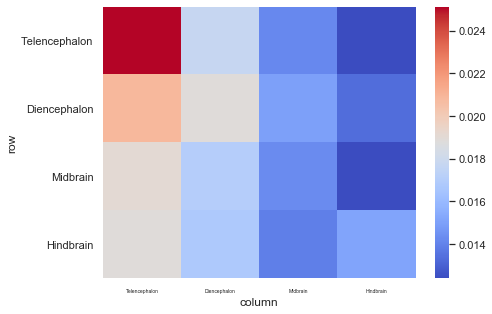

In [134]:
fig, ax = plt.subplots(figsize = ((7,5)))

a = ["Telencephalon", "Diencephalon", "Midbrain", "Hindbrain"]
b = ["Telencephalon", "Diencephalon", "Midbrain", "Hindbrain"]

prac = df.pivot('row','column','data')
prac = prac.reindex(index=a, columns=b)
ax = sns.heatmap(prac, cmap = 'coolwarm')
plt.xticks(size= '5')
plt.savefig(Ffig + 'CCM_network_mat_BLN.svg',transparent = True )
plt.show()


In [135]:
#GROUP FOC INTO AVERAGE PLOT
mode = 'coarse'

data_p5_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + 'PTZ05' + '_run-01_t' + '*xmap*')
coord_p5_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  'PTZ05' + '_run' + '*1_pre-CCM.npy*')
data_p5_l, coord_p5_l  

(['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5'],
 ['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-15_2photon

In [136]:
p5_ccm, row_v, col_v = ccm_mat(data_p5_l, coord_p5_l, mode)

/Users/dominicburrows/Dropbox/PhD/Analysis/my_scripts/GitHub/empirical_dynamic_modelling/CCM.py:138: H5pyDeprecationWarning: The default file mode will change to 'r' (read-only) in h5py 3.0. To suppress this warning, pass the mode you need to h5py.File(), or set the global default h5.get_config().default_file_mode, or set the environment variable H5PY_DEFAULT_READONLY=1. Available modes are: 'r', 'r+', 'w', 'w-'/'x', 'a'. See the docs for details.
  data = h5py.File(file)


Done 0 of 7
Done 1 of 7
Done 2 of 7
Done 3 of 7
Done 4 of 7
Done 5 of 7
Done 6 of 7


In [261]:
bln_ccm, p5_ccm

(array([0.02513769, 0.01773644, 0.01422465, 0.01238483, 0.02086526,
        0.01888475, 0.0150021 , 0.01333146, 0.01908858, 0.01704036,
        0.0143156 , 0.01240689, 0.01886133, 0.01680664, 0.01391811,
        0.01513074]),
 array([0.03995613, 0.03055626, 0.0251906 , 0.02517084, 0.0369225 ,
        0.03687375, 0.03116685, 0.02972853, 0.03180185, 0.03220228,
        0.03101217, 0.0271989 , 0.03290502, 0.03191146, 0.02830336,
        0.03254332]))

In [260]:
p5_ccm - bln_ccm

array([0.01481844, 0.01281982, 0.01096595, 0.012786  , 0.01605724,
       0.017989  , 0.01616475, 0.01639707, 0.01271327, 0.01516192,
       0.01669657, 0.01479201, 0.0140437 , 0.01510482, 0.01438525,
       0.01741258])

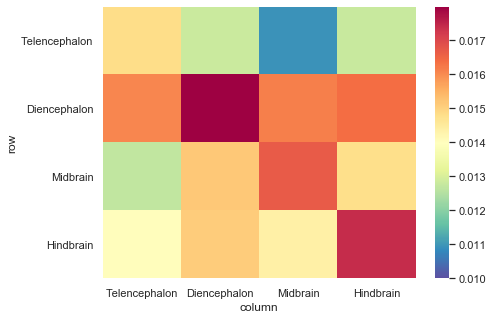

In [137]:
df = {'data': p5_ccm - bln_ccm,'row': row_v, 'column': col_v}
df = pd.DataFrame(df)

fig, ax = plt.subplots(figsize = ((7,5)))

a = ["Telencephalon", "Diencephalon", "Midbrain", "Hindbrain"]
b = ["Telencephalon", "Diencephalon", "Midbrain", "Hindbrain"]

prac = df.pivot('row','column','data')
prac = prac.reindex(index=a, columns=b)
ax = sns.heatmap(prac, cmap = 'Spectral_r', vmin = 0.01)
plt.savefig(Ffig + 'CCM_network_mat_PTZ05.svg',transparent = True )
plt.show()

In [361]:
0.06/16

0.00375

In [ ]:
import mne
d1 = bln_ccm_sig
d2 = p5_ccm_sig
p_vals = [] #add in p values from comparisons with enough data points

for x in range(d1.shape[1]): #loop through each label
    for y in range(d1.shape[2]): 
        data_1 = d1[:,x,y]
        data_2 = d2[:,x,y]
    
        p_vals = np.append(p_vals,adfn.stats_2samp(data_1, data_2, 0.05, 1, 'ind' )[1]) #Calculate p value

sig_v, adj_p_vals = mne.stats.fdr_correction(p_vals, 0.05, 'indep') #Use Benjamini hochberg FDR test 
print(sig_v)

In [ ]:
import mne
d1 = bln_ccm_gran
d2 = p5_ccm_gran
p_vals = [] #add in p values from comparisons with enough data points

for x in range(d1.shape[1]): #loop through each label
    for y in range(d1.shape[2]): 
        data_1 = d1[:,x,y]
        data_2 = d2[:,x,y]
        
        if sum(data_1 > 0) < 4 or sum(data_2>0) < 4:
            p_vals = np.append(p_vals,1000)
        
        else:
            p_vals = np.append(p_vals,adfn.stats_2samp(data_1, data_2, 0.05, 1, 'ind' )[1]) #Calculate p value

sig_v, adj_p_vals = mne.stats.fdr_correction(p_vals, 0.05, 'indep') #Use Benjamini hochberg FDR test 
print(sig_v) 

In [524]:
sig_v

array([False, False, False, ..., False, False, False])

In [526]:
sum(np.reshape(sig_v, (111,111)))

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0])

In [ ]:
import mne
d1 = bln_ccm_gran
d2 = p5_ccm_gran
p_vals = [] #add in p values from comparisons with enough data points

for x in range(d1.shape[1]): #loop through each label
    for y in range(d1.shape[2]): 
        data_1 = d1[:,x,y]
        data_2 = d2[:,x,y]
    
        p_vals = np.append(p_vals,adfn.stats_2samp(data_1, data_2, 0.05, 1, 'ind' )[1]) #Calculate p value

sig_v, adj_p_vals = mne.stats.fdr_correction(p_vals, 0.05, 'indep') #Use Benjamini hochberg FDR test 
print(sig_v)

In [138]:
p20_ccm, row_v, col_v = ccm_mat(data_p20_l, coord_p20_l, mode)

Done 0 of 5
Done 1 of 5
Done 2 of 5
Done 3 of 5
Done 4 of 5


In [279]:
bln_ccm, p20_ccm

(array([0.02513769, 0.01773644, 0.01422465, 0.01238483, 0.02086526,
        0.01888475, 0.0150021 , 0.01333146, 0.01908858, 0.01704036,
        0.0143156 , 0.01240689, 0.01886133, 0.01680664, 0.01391811,
        0.01513074]),
 array([0.1402296 , 0.12596039, 0.1203489 , 0.1082089 , 0.12810419,
        0.14084936, 0.13462617, 0.12642576, 0.12365855, 0.13689865,
        0.1371797 , 0.12457148, 0.11630509, 0.13668841, 0.13305925,
        0.1367873 ]))

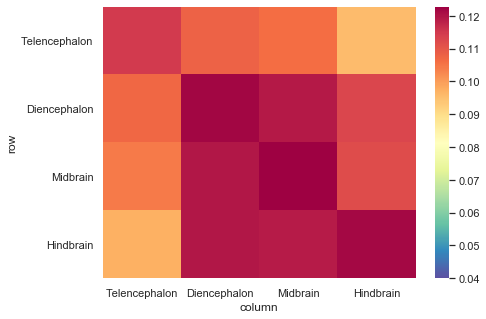

In [139]:
df = {'data': p20_ccm - bln_ccm,'row': row_v, 'column': col_v}
df = pd.DataFrame(df)

fig, ax = plt.subplots(figsize = ((7,5)))

a = ["Telencephalon", "Diencephalon", "Midbrain", "Hindbrain"]
b = ["Telencephalon", "Diencephalon", "Midbrain", "Hindbrain"]

prac = df.pivot('row','column','data')
prac = prac.reindex(index=a, columns=b)
ax = sns.heatmap(prac, cmap = 'Spectral_r', vmin = 0.04)


plt.savefig(Ffig + 'CCM_network_mat_PTZ20.svg',transparent = True )
plt.show()

In [374]:
np.reshape(p_vals < (0.05/16), (4,4))

array([[ True,  True,  True, False],
       [ True,  True,  True, False],
       [ True,  True,  True, False],
       [False, False, False, False]])

In [18]:
import mne
d1 = bln_ccm_gran
d2 = p20_ccm_gran
p_vals = [] #add in p values from comparisons with enough data points

for x in range(d1.shape[1]): #loop through each label
    for y in range(d1.shape[2]): 
        data_1 = d1[:,x,y]
        data_2 = d2[:,x,y]
    
        p_vals = np.append(p_vals,adfn.stats_2samp(data_1, data_2, 0.05, 1, 'ind' )[1]) #Calculate p value

sig_v, adj_p_vals = mne.stats.fdr_correction(p_vals, 0.05, 'indep') #Use Benjamini hochberg FDR test 
print(sig_v)

At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 5.0   p = 0.016894419691834778
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 4.0   p = 0.011635146004975378
At least one sample is non-Gaussian - performing non-parametric test
Samples are the same
U = 14.0   p = 0.20378102805923848
At least one sample is non-Gaussian - performing non-parametric test


ValueError: All numbers are identical in mannwhitneyu

In [15]:
d1.shape

(8, 4, 4)

In [13]:
out_hub  = np.sum(np.reshape(sig_v, (111,111)), axis=1) #Number of significantly changed outgoing causes (rows)
in_hub = np.sum(np.reshape(sig_v, (111,111)), axis=0) #Number of significantly changed outgoing causes (cols)

ValueError: cannot reshape array of size 16 into shape (111,111)

In [17]:
out_hub

array([42, 56,  0,  0, 56, 56, 51,  0, 60, 52,  0, 53,  0,  0,  0, 39,  0,
       50, 28, 59, 43, 44, 53, 50,  0, 60,  0,  0, 53, 59,  0,  0, 59, 59,
        0, 60, 59, 59,  0,  0,  0,  0, 55, 58,  0, 58, 59, 59, 47, 53, 46,
       31, 48, 36, 54, 32, 51, 41, 44, 54, 20, 29,  0, 53, 50, 56,  0, 44,
       47,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, 56, 52, 57, 52,  0, 57, 57,  0, 58, 57,
        0, 49,  0,  0,  0, 59, 59, 59, 38])

In [448]:
data_1, data_2

(array([0., 0., 0., 0., 0., 0., 0., 0.]), array([0., 0., 0., 0., 0.]))

In [ ]:
import mne
d1 = bln_ccm_gran
d2 = p20_ccm_gran
p_vals = [] #add in p values from comparisons with enough data points

for x in range(d1.shape[1]): #loop through each label
    for y in range(d1.shape[2]): 
        data_1 = d1[:,x,y]
        data_2 = d2[:,x,y]
        
        if sum(data_1 > 0) < 4 or sum(data_2>0) < 4:
            p_vals = np.append(p_vals,1000)
        
        else:
            p_vals = np.append(p_vals,adfn.stats_2samp(data_1, data_2, 0.05, 1, 'ind' )[1]) #Calculate p value

sig_v, adj_p_vals = mne.stats.fdr_correction(p_vals, 0.05, 'indep') #Use Benjamini hochberg FDR test 
print(sig_v) 

In [20]:
out_hub  = np.sum(np.reshape(sig_v, (111,111)), axis=1) #Number of significantly changed outgoing causes (rows)
in_hub = np.sum(np.reshape(sig_v, (111,111)), axis=0) #Number of significantly changed outgoing causes (cols)

In [142]:
np.reshape(sig_v, (111,111))

array([[False,  True, False, ...,  True,  True, False],
       [ True,  True, False, ...,  True,  True,  True],
       [False, False, False, ..., False, False, False],
       ...,
       [ True,  True, False, ...,  True,  True,  True],
       [ True,  True, False, ...,  True,  True,  True],
       [False,  True, False, ...,  True,  True, False]])

In [6]:
Fzbb = '/Users/dominicburrows/Dropbox/PhD/analysis/' + 'zbrain_stacks/'
atlasim = Fzbb + 'atlas/pajevic1.tif'
atlasli = Fzbb + 'atlas/Pajevic_annotations.csv'
atlaslab=pd.read_csv(atlasli, sep=',',header=None)

lab_unq = np.unique(np.array(atlaslab[1]))

(array([ 1.,  0.,  3.,  1.,  3.,  3.,  6.,  7., 11., 26.]),
 array([20., 24., 28., 32., 36., 40., 44., 48., 52., 56., 60.]),
 <a list of 10 Patch objects>)

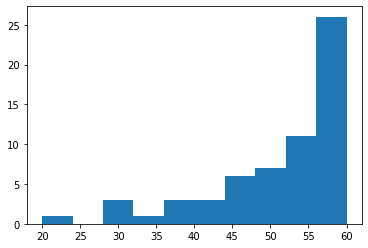

In [12]:
plt.hist(out_hub[out_hub>0])

(array([ 2.,  0.,  1.,  2.,  2.,  1.,  6.,  6., 10., 31.]),
 array([ 4. ,  9.7, 15.4, 21.1, 26.8, 32.5, 38.2, 43.9, 49.6, 55.3, 61. ]),
 <a list of 10 Patch objects>)

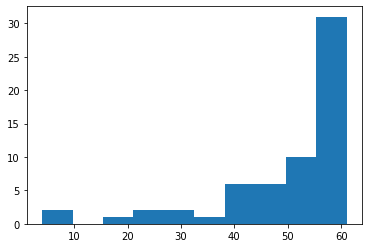

In [13]:
plt.hist(in_hub[in_hub>0])

In [140]:
d = {'data': out_hub[out_hub>55], 'label': lab_unq[out_hub > 55]}
df = pd.DataFrame(data=d)

In [ ]:
#SIGNIFICANT INCOMING VS OUTGOING HUBS with threshold
#POSITIVE MEANS MORE OUTGOING THAN INCOMING
from matplotlib import cm

upper = 10
lower = -6

diff = out_hub - in_hub
name = lab_unq[(diff > upper) | (diff<lower)]

d = {'data': diff[(diff > upper) | (diff<lower)], 'label': name}
df = pd.DataFrame(data=d)

# BASELINE -> FOCAL SEIZURE
colormap = cm.Spectral(np.linspace(0, 1, len(diff[(diff > upper) | (diff<lower)])))

fig, ax = plt.subplots(figsize = ((12,20)))
ax = sns.barplot(y="label", x="data", palette = colormap, data=df)
plt.yticks(fontsize=30)
plt.xticks(fontsize=5)
plt.savefig(Ffig + 'out_in_bar_CCM.svg', transparent=True)
plt.show()


In [156]:
ok = out_hub[out_hub>thresh][::2]

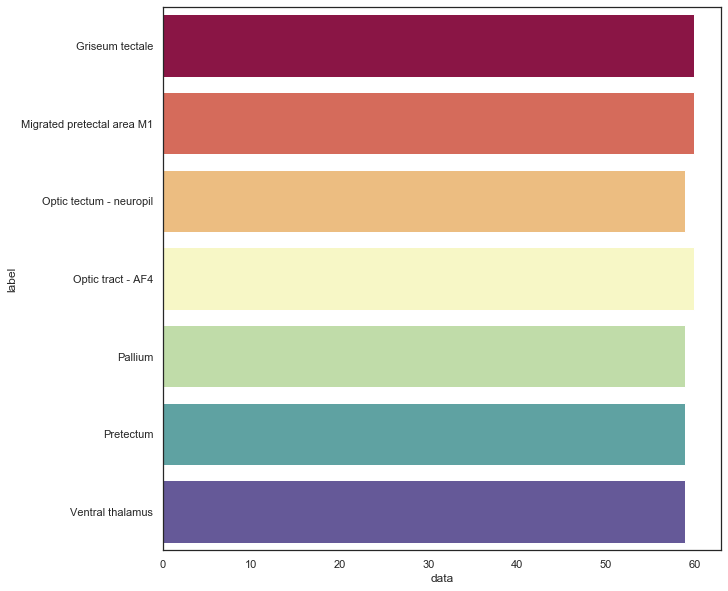

In [161]:
#SIGNIFICANT OUTGOING HUBS -> BLN -> PTZ20
from matplotlib import cm

thresh = 58
colormap = cm.Spectral(np.linspace(0, 1, len(ok)))

d = {'data': ok, 'label': lab_unq[out_hub>thresh][::2]}
df = pd.DataFrame(data=d)


fig, ax = plt.subplots(figsize = ((10,10)))
ax = sns.barplot(y="label", x="data", palette = colormap, data=df)

plt.show()

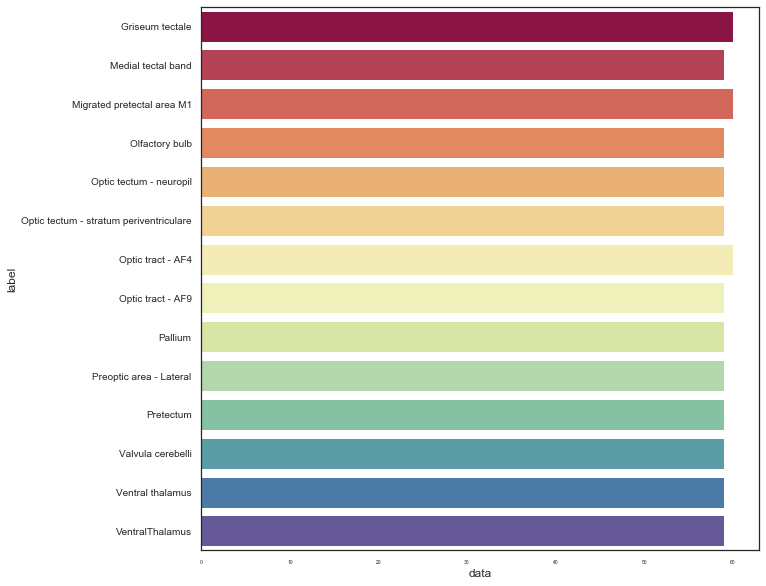

In [179]:
#SIGNIFICANT OUTGOING HUBS -> BLN -> PTZ20
from matplotlib import cm

thresh = 58
colormap = cm.Spectral(np.linspace(0, 1, len(out_hub[out_hub>thresh])))

d = {'data': out_hub[out_hub>thresh], 'label': lab_unq[out_hub > thresh]}
df = pd.DataFrame(data=d)


fig, ax = plt.subplots(figsize = ((10,10)))
ax = sns.barplot(y="label", x="data", palette = colormap, data=df)
plt.yticks(fontsize=10)
plt.xticks(fontsize=5)
plt.savefig(Ffig + 'out_bar_CCM.svg', transparent=True)

plt.show()


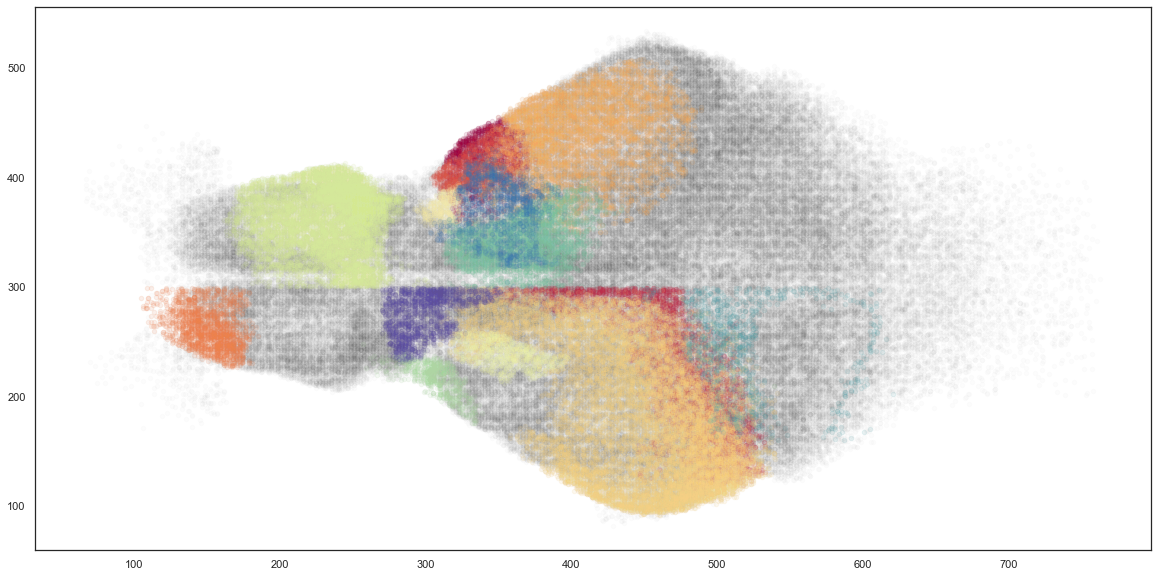

In [172]:
#PLOT LIN VS NONLIN - BLN
fig,axarr = plt.subplots(figsize = (20,10))

from matplotlib import pyplot as plt

plt.scatter(all_mat[:,1], all_mat[:,0],  s = 20, c = 'grey', alpha = 0.02) #plot all neurons
for x,lab in enumerate(d['label']):
    above_ind = lab_dic[lab][:,0] > 300
    below_ind = lab_dic[lab][:,0] < 300
    if x % 2 == 0:
        plt.scatter(lab_dic[lab][:,1][above_ind], lab_dic[lab][:,0][above_ind],  s = 20, c = np.reshape(colormap[x], (1,4)), alpha = 0.1) #plot all neurons
    else:
        plt.scatter(lab_dic[lab][:,1][below_ind], lab_dic[lab][:,0][below_ind],  s = 20, c = np.reshape(colormap[x], (1,4)), alpha = 0.1) #plot all neurons


plt.savefig(Ffig + 'out_CCM.png',transparent = True )
plt.show()


In [ ]:
#PLOT LIN VS NONLIN - BLN
fig,axarr = plt.subplots(figsize = (20,10))

from matplotlib import pyplot as plt

plt.scatter(all_mat[:,1], all_mat[:,0],  s = 20, c = 'grey', alpha = 0.02) #plot all neurons
for x,lab in enumerate(d['label']):
    above_ind = lab_dic[lab][:,0] > 300
    below_ind = lab_dic[lab][:,0] < 300
    if d['data'][x] >= 0 :
        plt.scatter(lab_dic[lab][:,1][above_ind], lab_dic[lab][:,0][above_ind],  s = 20, c = np.reshape(colormap[x], (1,4)), alpha = 1) #plot all neurons
    else:
        plt.scatter(lab_dic[lab][:,1][below_ind], lab_dic[lab][:,0][below_ind],  s = 20, c = np.reshape(colormap[x], (1,4)), alpha = 1) #plot all neurons

plt.savefig(Ffig + 'out_in_CCM.png',transparent = True )
plt.show()


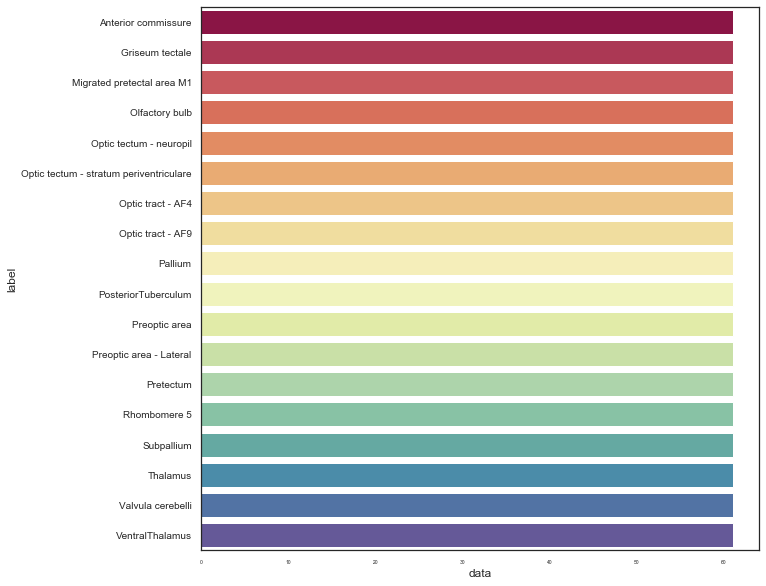

In [181]:
#SIGNIFICANT INCOMING HUBS
from matplotlib import cm

thresh = 60
colormap = cm.Spectral(np.linspace(0, 1, len(in_hub[in_hub>thresh])))
d = {'data': in_hub[in_hub>thresh], 'label': lab_unq[in_hub > thresh]}
df = pd.DataFrame(data=d)

# BASELINE -> GEN SEIZURE

fig, ax = plt.subplots(figsize = ((10,10)))
ax = sns.barplot(y="label", x="data", palette = colormap, data=df)
plt.yticks(fontsize=10)
plt.xticks(fontsize=5)
plt.savefig(Ffig + 'in_bar_CCM.svg', transparent=True)
plt.show()

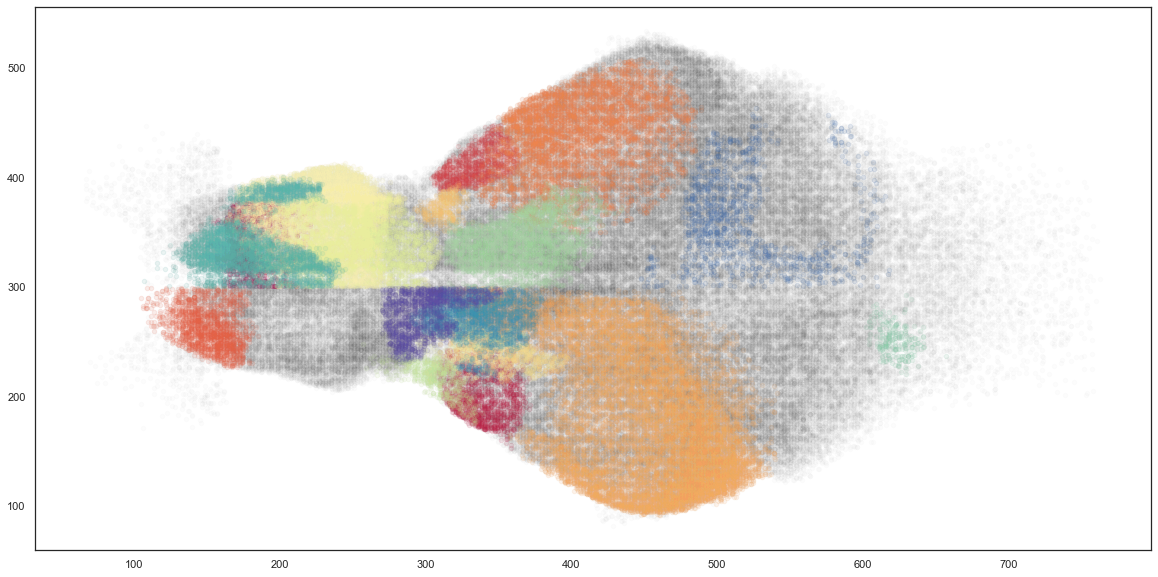

In [174]:
#PLOT LIN VS NONLIN - BLN
fig,axarr = plt.subplots(figsize = (20,10))

from matplotlib import pyplot as plt

plt.scatter(all_mat[:,1], all_mat[:,0],  s = 20, c = 'grey', alpha = 0.02) #plot all neurons
for x,lab in enumerate(d['label']):
    above_ind = lab_dic[lab][:,0] > 300
    below_ind = lab_dic[lab][:,0] < 300
    if x % 2 == 0:
        plt.scatter(lab_dic[lab][:,1][above_ind], lab_dic[lab][:,0][above_ind],  s = 20, c = np.reshape(colormap[x], (1,4)), alpha = 0.1) #plot all neurons
    else:
        plt.scatter(lab_dic[lab][:,1][below_ind], lab_dic[lab][:,0][below_ind],  s = 20, c = np.reshape(colormap[x], (1,4)), alpha = 0.1) #plot all neurons

plt.savefig(Ffig + 'in_CCM.png',transparent = True )
plt.show()


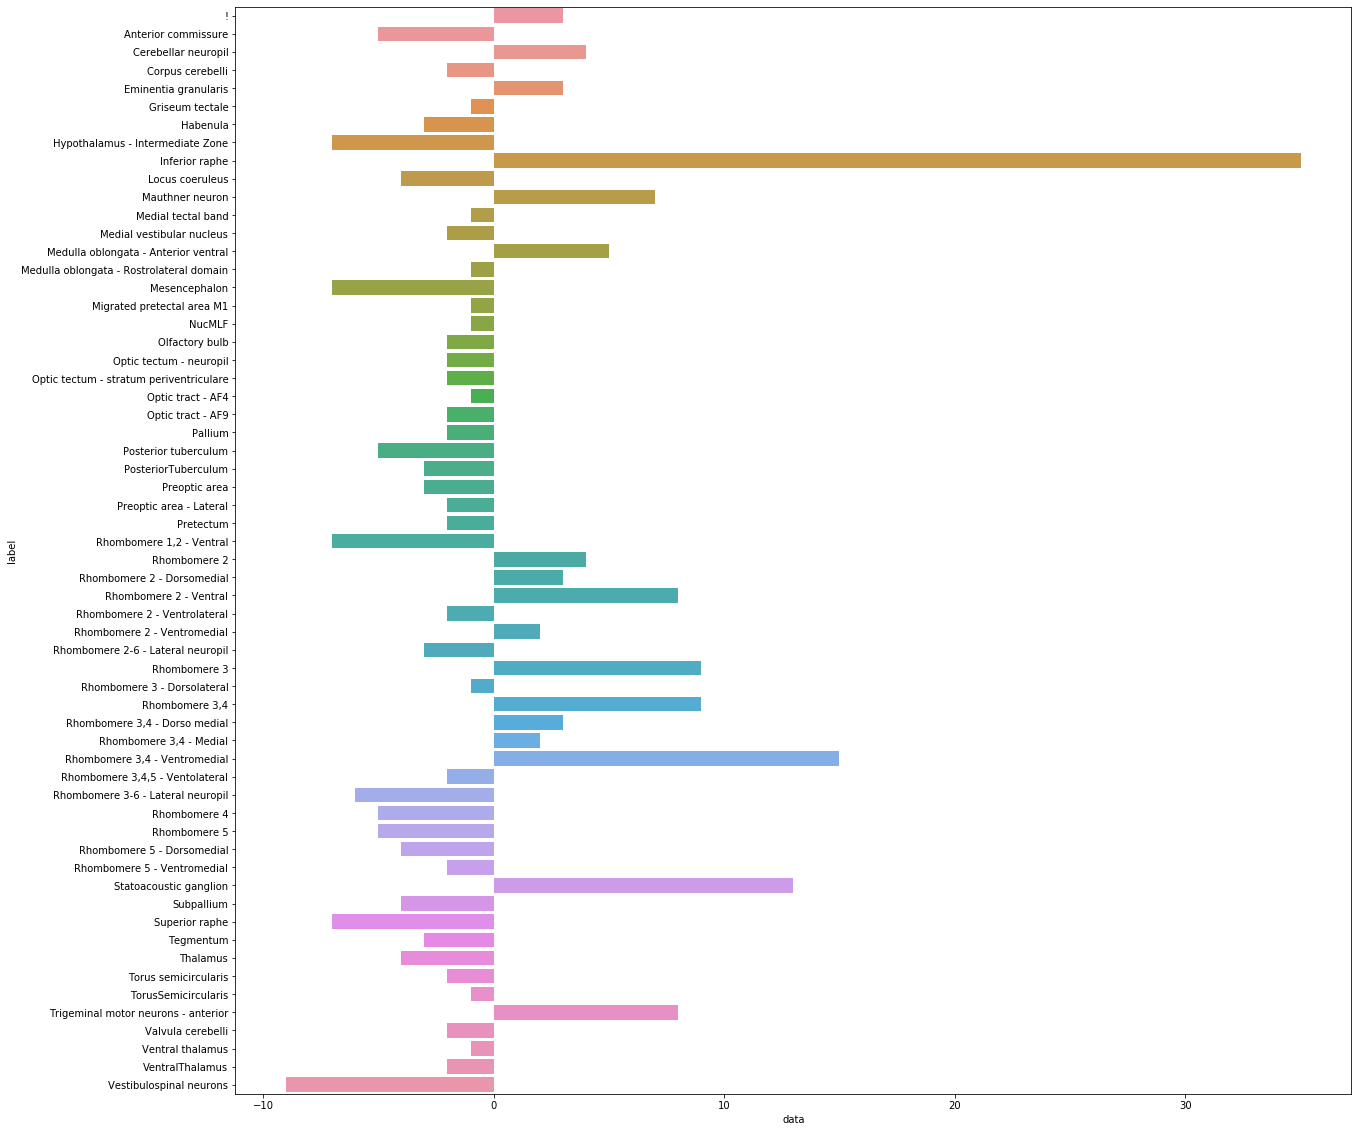

In [135]:
#SIGNIFICANT INCOMING VS OUTGOING HUBS
#POSITIVE MEANS MORE OUTGOING THAN INCOMING

diff = out_hub - in_hub
name = lab_unq[diff != 0]

d = {'data': diff[diff != 0], 'label': name}
df = pd.DataFrame(data=d)

# BASELINE -> FOCAL SEIZURE

fig, ax = plt.subplots(figsize = ((20,20)))
ax = sns.barplot(y="label", x="data", data=df)

plt.show()

In [136]:
diff

array([ 3, -5,  0,  0,  4, -2,  3,  0, -1, -3,  0, -7,  0,  0,  0, 35,  0,
       -4,  7, -1, -2,  5, -1, -7,  0, -1,  0,  0, -1, -2,  0,  0, -2, -2,
        0, -1, -2, -2,  0,  0,  0,  0, -5, -3,  0, -3, -2, -2, -7,  4,  3,
        8, -2,  2, -3,  9, -1,  9,  3,  2, 15, -2,  0, -6, -5, -5,  0, -4,
       -2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0, 13, -4, -7,  0, -3, -4,  0, -2, -1,
        0,  8,  0,  0,  0, -2, -1, -2, -9])

In [606]:
diff[(diff > 5) | (diff<-5)]

array([-7, 35,  7, -7, -7,  8,  9,  9, 15, -6, 13, -7,  8, -9])

In [138]:
len(diff[(diff > upper) | (diff<lower)])

array([-7, 35,  7, -7, -7,  8,  9,  9, 15, -6, 13, -7,  8, -9])

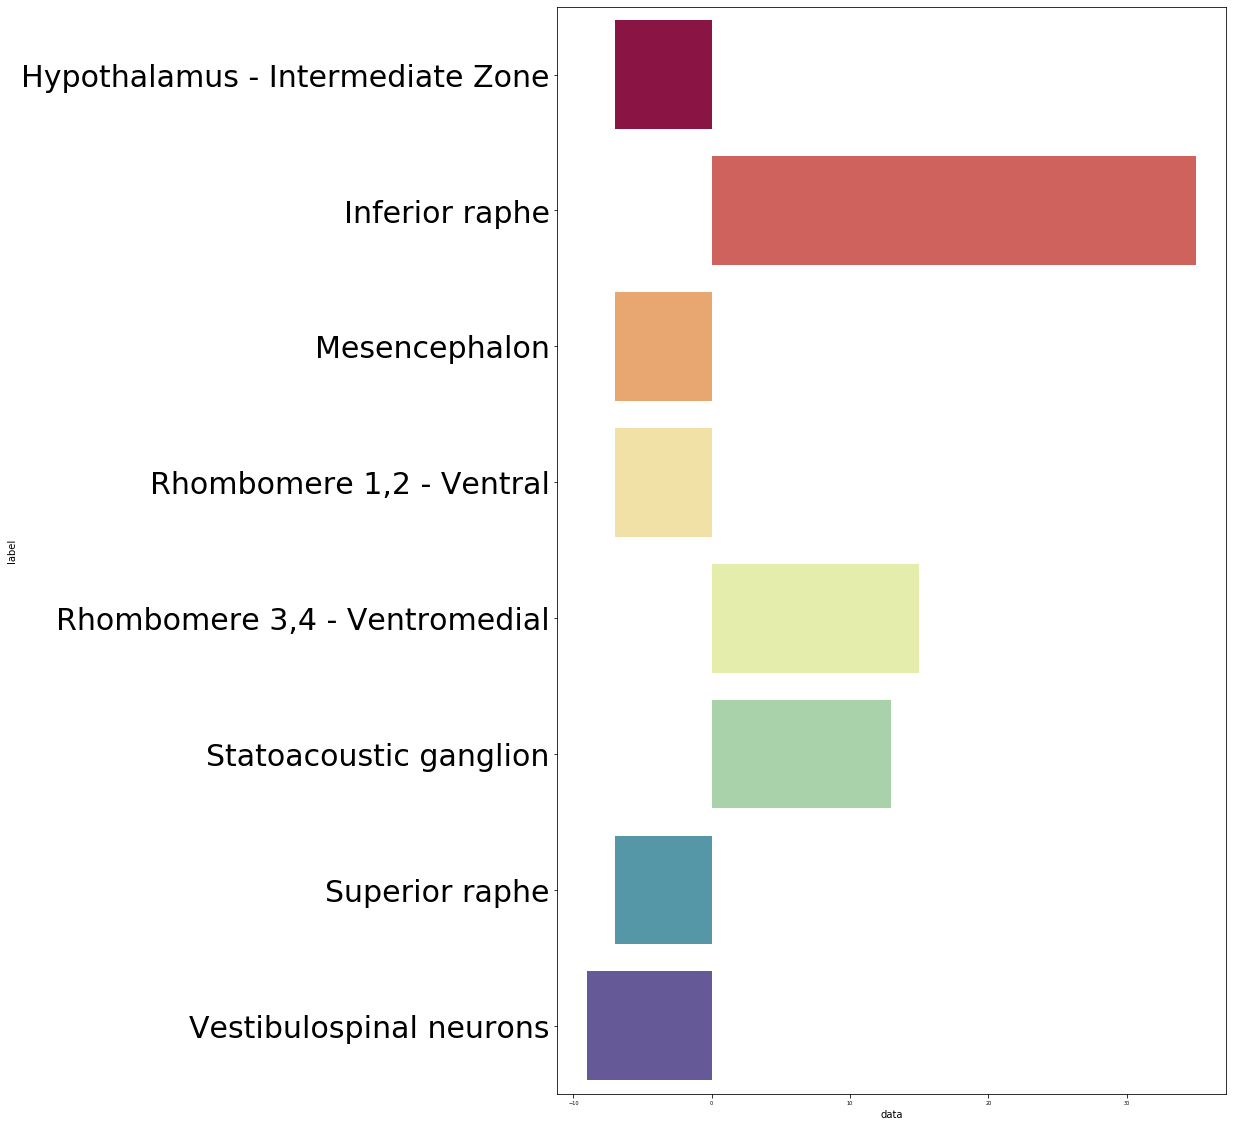

In [45]:
#SIGNIFICANT INCOMING VS OUTGOING HUBS with threshold
#POSITIVE MEANS MORE OUTGOING THAN INCOMING
from matplotlib import cm

upper = 10
lower = -6

diff = out_hub - in_hub
name = lab_unq[(diff > upper) | (diff<lower)]

d = {'data': diff[(diff > upper) | (diff<lower)], 'label': name}
df = pd.DataFrame(data=d)

# BASELINE -> FOCAL SEIZURE
colormap = cm.Spectral(np.linspace(0, 1, len(diff[(diff > upper) | (diff<lower)])))

fig, ax = plt.subplots(figsize = ((12,20)))
ax = sns.barplot(y="label", x="data", palette = colormap, data=df)
plt.yticks(fontsize=30)
plt.xticks(fontsize=5)
plt.savefig(Ffig + 'out_in_bar_CCM.svg', transparent=True)
plt.show()


In [27]:
all_mat= np.load('coord_all.npy')
lab_dic = np.load('coord_labels_gran.npy', allow_pickle=True).item()

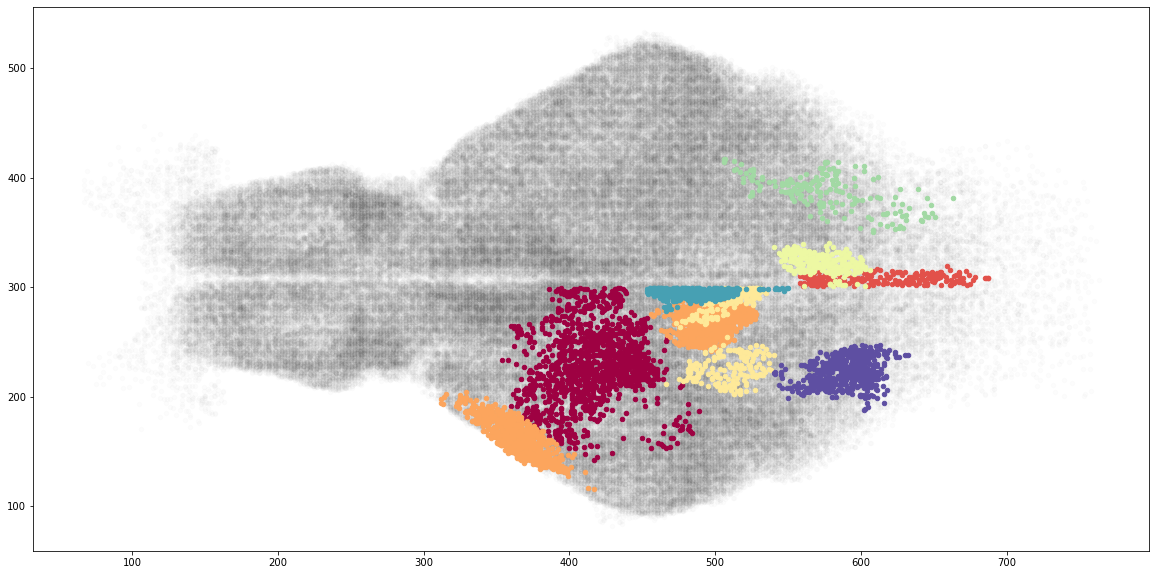

In [39]:
#PLOT LIN VS NONLIN - BLN
fig,axarr = plt.subplots(figsize = (20,10))

from matplotlib import pyplot as plt

plt.scatter(all_mat[:,1], all_mat[:,0],  s = 20, c = 'grey', alpha = 0.02) #plot all neurons
for x,lab in enumerate(d['label']):
    above_ind = lab_dic[lab][:,0] > 300
    below_ind = lab_dic[lab][:,0] < 300
    if d['data'][x] >= 0 :
        plt.scatter(lab_dic[lab][:,1][above_ind], lab_dic[lab][:,0][above_ind],  s = 20, c = np.reshape(colormap[x], (1,4)), alpha = 1) #plot all neurons
    else:
        plt.scatter(lab_dic[lab][:,1][below_ind], lab_dic[lab][:,0][below_ind],  s = 20, c = np.reshape(colormap[x], (1,4)), alpha = 1) #plot all neurons

plt.savefig(Ffig + 'out_in_CCM.png',transparent = True )
plt.show()


In [587]:
np.where((a > 230)  (a < 240), True, False)

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
       False,  True, False,  True, False, False,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False])

In [592]:
diff > 5

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
       False,  True, False,  True, False, False,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False])

In [594]:
np.where((diff > 5) or (diff < -5))

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [581]:
diff = out_hub - in_hub
name = lab_unq[diff != 0]
name

array(['!', 'Anterior commissure', 'Cerebellar neuropil',
       'Corpus cerebelli', 'Eminentia granularis', 'Griseum tectale',
       'Habenula', 'Hypothalamus - Intermediate Zone', 'Inferior raphe',
       'Locus coeruleus', 'Mauthner neuron', 'Medial tectal band',
       'Medial vestibular nucleus',
       'Medulla oblongata - Anterior ventral',
       'Medulla oblongata - Rostrolateral domain', 'Mesencephalon',
       'Migrated pretectal area M1', 'NucMLF', 'Olfactory bulb',
       'Optic tectum - neuropil',
       'Optic tectum - stratum periventriculare', 'Optic tract - AF4',
       'Optic tract - AF9', 'Pallium', 'Posterior tuberculum',
       'PosteriorTuberculum', 'Preoptic area', 'Preoptic area - Lateral',
       'Pretectum', 'Rhombomere 1,2 - Ventral', 'Rhombomere 2',
       'Rhombomere 2 - Dorsomedial', 'Rhombomere 2 - Ventral',
       'Rhombomere 2 - Ventrolateral', 'Rhombomere 2 - Ventromedial',
       'Rhombomere 2-6 - Lateral neuropil', 'Rhombomere 3',
       'Rhombomer

In [580]:
out_hub, in_hub

array([42, 56,  0,  0, 56, 56, 51,  0, 60, 52,  0, 53,  0,  0,  0, 39,  0,
       50, 28, 59, 43, 44, 53, 50,  0, 60,  0,  0, 53, 59,  0,  0, 59, 59,
        0, 60, 59, 59,  0,  0,  0,  0, 55, 58,  0, 58, 59, 59, 47, 53, 46,
       31, 48, 36, 54, 32, 51, 41, 44, 54, 20, 29,  0, 53, 50, 56,  0, 44,
       47,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, 56, 52, 57, 52,  0, 57, 57,  0, 58, 57,
        0, 49,  0,  0,  0, 59, 59, 59, 38])

In [578]:
lab_unq.shape

(111,)

In [558]:
lab_unq[out_hub > 55]

array(['Anterior commissure', 'Cerebellar neuropil', 'Corpus cerebelli',
       'Griseum tectale', 'Medial tectal band',
       'Migrated pretectal area M1', 'Olfactory bulb',
       'Optic tectum - neuropil',
       'Optic tectum - stratum periventriculare', 'Optic tract - AF4',
       'Optic tract - AF9', 'Pallium', 'PosteriorTuberculum',
       'Preoptic area', 'Preoptic area - Lateral', 'Pretectum',
       'Rhombomere 5', 'Rhombomere1', 'Subpallium', 'Tegmentum',
       'Thalamus', 'Torus semicircularis', 'TorusSemicircularis',
       'Valvula cerebelli', 'Ventral thalamus', 'VentralThalamus'],
      dtype=object)

In [574]:
out_hub - in_hub

array([ 3, -5,  0,  0,  4, -2,  3,  0, -1, -3,  0, -7,  0,  0,  0, 35,  0,
       -4,  7, -1, -2,  5, -1, -7,  0, -1,  0,  0, -1, -2,  0,  0, -2, -2,
        0, -1, -2, -2,  0,  0,  0,  0, -5, -3,  0, -3, -2, -2, -7,  4,  3,
        8, -2,  2, -3,  9, -1,  9,  3,  2, 15, -2,  0, -6, -5, -5,  0, -4,
       -2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0, 13, -4, -7,  0, -3, -4,  0, -2, -1,
        0,  8,  0,  0,  0, -2, -1, -2, -9])

In [530]:
out_hub  = np.sum(np.reshape(sig_v, (111,111)), axis=1) #Number of significantly changed outgoing causes (rows)
in_hub = np.sum(np.reshape(sig_v, (111,111)), axis=0) #Number of significantly changed outgoing causes (cols)

In [512]:
lab_unq[out_hub > 112]

array(['Optic tectum - neuropil', 'Optic tectum - neuropil',
       'Optic tectum - stratum periventriculare', 'Torus semicircularis',
       'Preoptic area - Lateral', 'Optic tectum - neuropil',
       'Migrated pretectal area M1',
       'Optic tectum - stratum periventriculare', 'PosteriorTuberculum',
       'Optic tectum - neuropil',
       'Optic tectum - stratum periventriculare', 'Optic tract - AF4',
       'Torus semicircularis', 'Optic tectum - neuropil',
       'Griseum tectale', 'Torus semicircularis', 'Torus semicircularis',
       'Optic tectum - stratum periventriculare', 'Torus semicircularis',
       'Optic tract - AF9'], dtype=object)

In [514]:
lab_unq.shape

(181,)

In [516]:
np.unique(lab_unq).shape

(111,)

In [510]:
lab_unq[in_hub > 112]

array(['Optic tectum - neuropil', 'Pallium', 'Posterior tuberculum',
       'Rhombomere 2-6 - Lateral neuropil', 'Optic tectum - neuropil',
       'Tegmentum', 'Rhombomere 4',
       'Optic tectum - stratum periventriculare', 'Subpallium',
       'Tegmentum', 'Torus semicircularis', 'Pallium',
       'Preoptic area - Lateral', 'Optic tectum - neuropil',
       'Migrated pretectal area M1', 'Rhombomere 2 - Ventrolateral',
       'VentralThalamus', 'Valvula cerebelli',
       'Optic tectum - stratum periventriculare', 'Rhombomere 5',
       'Preoptic area', 'Tegmentum', 'Medial tectal band', 'Subpallium',
       'Pallium', 'PosteriorTuberculum', 'Superior raphe',
       'Optic tectum - neuropil', 'Pretectum',
       'Optic tectum - stratum periventriculare', 'Tegmentum',
       'Valvula cerebelli', 'Optic tract - AF4', 'Torus semicircularis',
       'Olfactory bulb', 'Preoptic area', 'Corpus cerebelli',
       'Optic tectum - neuropil', 'Griseum tectale', 'Tegmentum',
       'Ventral tha

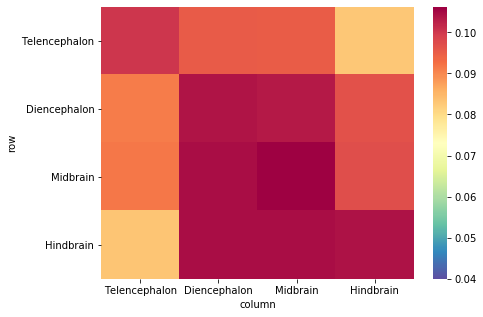

In [311]:
df = {'data': p20_ccm - p5_ccm,'row': row_v, 'column': col_v}
df = pd.DataFrame(df)

fig, ax = plt.subplots(figsize = ((7,5)))

a = ["Telencephalon", "Diencephalon", "Midbrain", "Hindbrain"]
b = ["Telencephalon", "Diencephalon", "Midbrain", "Hindbrain"]

prac = df.pivot('row','column','data')
prac = prac.reindex(index=a, columns=b)
ax = sns.heatmap(prac, cmap = 'Spectral_r', vmin = 0.04)


In [371]:
np.reshape(sig_v, (4,4))

array([[ True,  True,  True, False],
       [ True,  True,  True, False],
       [ True,  True,  True, False],
       [ True,  True,  True, False]])

In [367]:
import mne
d1 = p5_ccm_sig
d2 = p20_ccm_sig
p_vals = [] #add in p values from comparisons with enough data points

for x in range(d1.shape[1]): #loop through each label
    for y in range(d1.shape[2]): 
        data_1 = d1[:,x,y]
        data_2 = d2[:,x,y]
    
        p_vals = np.append(p_vals,adfn.stats_2samp(data_1, data_2, 0.05, 1, 'ind' )[1]) #Calculate p value

sig_v, adj_p_vals = mne.stats.fdr_correction(p_vals, 0.05, 'indep') #Use Benjamini hochberg FDR test 
print(sig_v)

At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 0.0   p = 0.0028830604571186305
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 0.0   p = 0.0028830604571186305
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 0.0   p = 0.0028830604571186305
At least one sample is non-Gaussian - performing non-parametric test
Samples are the same
U = 7.0   p = 0.052188343299878044
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 0.0   p = 0.0028830604571186305
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 0.0   p = 0.0028830604571186305
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 1.0   p = 0.004683055816533359
At least one sample is non-Gau

In [370]:
np.reshape(sig_v, (4,4))

array([[ True,  True,  True, False],
       [ True,  True,  True, False],
       [ True,  True,  True, False],
       [ True,  True,  True, False]])

In [20]:
#Significance testing by area

#Label matrix

#Bar graph


(11038, 11038)

In [ ]:
# WHAT ABOUT EMPTY REGIONS - REGIONS RETAIN LABELS - ONLY DO MAPPING OF SHARED LABELS

In [204]:
data_vec, dlabel_vec, plabel_vec = [],[],[] #vectors for data, driver label and passenger label
for x, l1 in enumerate(lab): #loop through each brain region - rows
    for y,l2 in enumerate(lab): #loop through each brain region - columns
        effect_vec = curr_coord == l1 #binary vector containing the effect of variable of interest (row variable)
        cause_vec = curr_coord == l2 #binary vector containing the cause of variable of interest (column variable)
        dlabel_vec, plabel_vec = np.append(dlabel_vec,l1), np.append(plabel_vec,l2)
        data_vec = np.append(data_vec,np.mean(ccm[effect_vec][:,cause_vec])) #Find mean value
        
        
        #lab_mat[x,y] = np.mean(ccm[effect_vec][:,cause_vec]) #Find mean value

In [205]:
df = {'data': data_vec ,'driver':dlabel_vec, 'passenger': plabel_vec}
df = pd.DataFrame(df)
df

,data,driver,passenger
0,0.066739,Telencephalon,Telencephalon
1,0.071125,Telencephalon,Diencephalon
2,0.058725,Telencephalon,Midbrain
3,0.055496,Telencephalon,Hindbrain
4,0.074525,Diencephalon,Telencephalon
5,0.098072,Diencephalon,Diencephalon
6,0.081183,Diencephalon,Midbrain
7,0.072440,Diencephalon,Hindbrain
8,0.068524,Midbrain,Telencephalon
9,0.089926,Midbrain,Diencephalon


In [207]:
prac = df.pivot('driver','passenger','data')
prac

passenger,Diencephalon,Hindbrain,Midbrain,Telencephalon
driver,,,,
Diencephalon,0.098072,0.072440,0.081183,0.074525
Hindbrain,0.084061,0.068327,0.070135,0.067098
Midbrain,0.089926,0.067598,0.075436,0.068524
Telencephalon,0.071125,0.055496,0.058725,0.066739


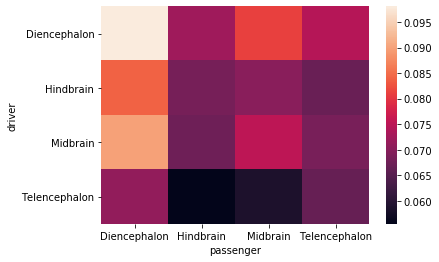

In [208]:
#USE ORDER I WANT! 
ax = sns.heatmap(prac)

In [ ]:
## ICTAL NETWORK DIVERSITY


In [46]:
#CAUSAL SEIZURE NETWORK CHANGES

#DUMB function for grouping mean ccm values into matrix
def ccm_mat(data_l, coord_l, mode):
    ccm_v = np.zeros((16)) #vector representation of ccm matrix

    for b in range(len(data_l)):

        ccm = cfn.ccm_stats(data_l[b], 'ccm')
        coord = np.load(coord_l[b], allow_pickle=True).item()['coord']


        #Choose granularity of cell labelling
        if mode == 'coarse':
            lab_v = coord[:,4] #coord labels - coarse 
            lab_unq = np.array(['Telencephalon', 'Diencephalon', 'Midbrain', 'Hindbrain']) #Order labels and choose major brain regions

        if mode == 'gran':
            lab_v = coord[:,3] #coord labels - granular
            lab_unq = np.unique(lab_v)


        #Initialise heatmap
        ccm_mat = np.zeros((lab_unq.shape[0], lab_unq.shape[0])) #create mean matrix to put data into
        row_v, col_v = [],[] #Vectors of row and column labels
        count=0
        #Loop over all labels
        for x,l1 in enumerate(lab_unq):
            curr_row = np.where(lab_v == l1)[0]

            for y,l2 in enumerate(lab_unq):
                curr_col = np.where(lab_v == l2)[0]

                #extend into 2 long vectors containing all cells which cover l1->l2
                #Extended row values -> repeat each element n times (n is num of column elements)
                ext_row = np.repeat(curr_row, curr_col.shape[0])

                #Extended col values -> repeat entire vector m times (m is num of row elements)
                ext_col = np.tile(curr_col, curr_row.shape[0])

                mean_ccm = np.mean(ccm[ext_row, ext_col]) #Calculate mean ccm value over all elements
                row_v, col_v = np.append(row_v,l1), np.append(col_v, l2)
                #ccm_mat[x,y] = mean_ccm
                ccm_v[count] += mean_ccm
                count+=1
        print('Done ' + str(b) + ' of ' + str(len(data_l)))

    return(ccm_v/count, row_v, col_v)

In [8]:
#GROUP ALL BASELINE INTO AVERAGE PLOT

data_bln_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + 'BLN' + '_run-01_t' + '*xmap*')
coord_bln_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  'BLN' + '_run' + '*1_pre-CCM.npy*')
data_bln_l, coord_bln_l  

(['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-15_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5'],
 ['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_BLN_run-0

In [17]:
#BLN
bln_v_l = list(range(len(data_bln_l)))
for i in range(len(data_bln_l)):
    bln_v_l[i] = ccm_net_vec(data_bln_l[i], coord_bln_l[i])
    print(i)

/Users/dominicburrows/Dropbox/PhD/Analysis/my_scripts/GitHub/empirical_dynamic_modelling/CCM.py:138: H5pyDeprecationWarning: The default file mode will change to 'r' (read-only) in h5py 3.0. To suppress this warning, pass the mode you need to h5py.File(), or set the global default h5.get_config().default_file_mode, or set the environment variable H5PY_DEFAULT_READONLY=1. Available modes are: 'r', 'r+', 'w', 'w-'/'x', 'a'. See the docs for details.
  data = h5py.File(file)


0
1
2
3
4
5
6
7


In [2]:


data_p5_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + 'PTZ05' + '_run-01_t' + '*xmap*')
coord_p5_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  'PTZ05' + '_run' + '*1_pre-CCM.npy*')
data_p5_l, coord_p5_l  

(['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5'],
 ['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-15_2photon

In [18]:
#FOC
p5_v_l = list(range(len(data_p5_l)))
for i in range(len(data_p5_l)):
    p5_v_l[i] = ccm_net_vec(data_p5_l[i], coord_p5_l[i])
    print(i)

0
1
2
3
4
5
6


In [20]:

data_p20_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + 'PTZ20' + '_run-01_t' + '*xmap*')
coord_p20_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  'PTZ20' + '_run' + '*1_pre-CCM.npy*')
data_p20_l, coord_p20_l  

(['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5'],
 ['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy'])

In [21]:
#GEN
p20_v_l = list(range(len(data_p20_l)))
for i in range(len(data_p20_l)):
    p20_v_l[i] = ccm_net_vec(data_p20_l[i], coord_p20_l[i])
    print(i)

0
1
2
3
4


In [55]:
def nonlinembed(data):
    from sklearn.manifold import Isomap

    embedding = Isomap(n_components=3)
    X_transformed = embedding.fit_transform(data)
    return(X_transformed)

In [22]:
comb_m = np.vstack((bln_v_l, np.vstack((p5_v_l, p20_v_l))))
comb_m.shape

(20, 12321)

In [57]:
embed = nonlinembed(comb_m)

In [84]:
len(p5_v_l)

7

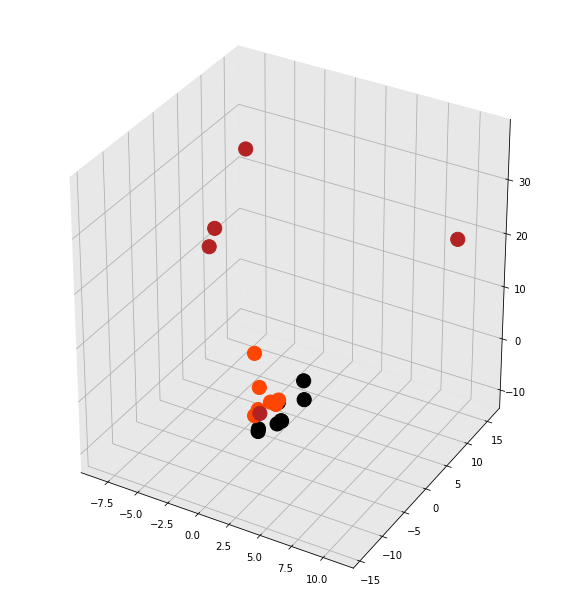

In [63]:
from mpl_toolkits.mplot3d import Axes3D
col_list = ['k', 'orangered','firebrick']
#Visualise one dataset in 3d

fig = plt.figure(figsize = (10,11))

ax = fig.add_subplot(111, projection='3d')

ax.scatter3D(embed[:8,2],embed[:8,1],embed[:8,0], s=200, c = 'k' , alpha = 1)
ax.scatter3D(embed[8:15,2],embed[8:15,1],embed[8:15,0], s=200, c = 'orangered', alpha = 1)

ax.scatter3D(embed[15:,2],embed[15:,1],embed[15:,0], s=200, c = 'firebrick', alpha = 1)

ax.w_xaxis.set_pane_color((0.9, 0.9, 0.9, 0.9))
ax.w_yaxis.set_pane_color((0.9, 0.9, 0.9, 0.9))
ax.w_zaxis.set_pane_color((0.9, 0.9, 0.9, 0.9))
plt.savefig(Ffig + 'CCM_diversity_embed.svg', transparent=True)
plt.show()


In [97]:
bln_v_l

[array([0.02633684, 0.0248803 , 0.00979138, ..., 0.0525976 , 0.10779867,
        0.08149868]),
 array([0.0281035 , 0.0075377 , 0.00269189, ..., 0.0012838 , 0.00464764,
        0.07154321]),
 array([0.08294005, 0.00848644, 0.00566568, ..., 0.00362298, 0.0109506 ,
        0.04986975]),
 array([0.12196444, 0.10772334, 0.        , ..., 0.08624318, 0.1443264 ,
        0.07309652]),
 array([0.06468873, 0.06672289, 0.01689893, ..., 0.0045888 , 0.00550196,
        0.028084  ]),
 array([0.01008386, 0.05329173, 0.00530805, ..., 0.03573025, 0.02018424,
        0.02009428]),
 array([0.04526768, 0.01687116, 0.        , ..., 0.00478145, 0.01239172,
        0.02800391]),
 array([0.10514186, 0.08341354, 0.        , ..., 0.02823733, 0.04393993,
        0.11427887])]

In [99]:
bln_v_l

[array([0.02633684, 0.0248803 , 0.00979138, ..., 0.0525976 , 0.10779867,
        0.08149868]),
 array([0.0281035 , 0.0075377 , 0.00269189, ..., 0.0012838 , 0.00464764,
        0.07154321]),
 array([0.08294005, 0.00848644, 0.00566568, ..., 0.00362298, 0.0109506 ,
        0.04986975]),
 array([0.12196444, 0.10772334, 0.        , ..., 0.08624318, 0.1443264 ,
        0.07309652]),
 array([0.06468873, 0.06672289, 0.01689893, ..., 0.0045888 , 0.00550196,
        0.028084  ]),
 array([0.01008386, 0.05329173, 0.00530805, ..., 0.03573025, 0.02018424,
        0.02009428]),
 array([0.04526768, 0.01687116, 0.        , ..., 0.00478145, 0.01239172,
        0.02800391]),
 array([0.10514186, 0.08341354, 0.        , ..., 0.02823733, 0.04393993,
        0.11427887])]

In [171]:
bln_v_l[0]

array([0.02633684, 0.0248803 , 0.00979138, ..., 0.0525976 , 0.10779867,
       0.08149868])

In [3]:
def mean_cross_dis(curr_l1, curr_l2):
    
    

    mean_d = np.zeros((len(curr_l1)))
    for i in range(len(curr_l1)):
        curr = curr_l1[i]
        
        sum_d = 0
        
        for e in range(len(curr_l2)):
            neigh = curr_l2[e]
            dist = np.linalg.norm(curr-neigh)
            sum_d +=dist
            
            if e == len(curr_l2)-1:
                mean_d[i] = sum_d/(e)

        
    return(mean_d)


In [4]:
def mean_self_dis(curr_l):

    mean_d = np.zeros((len(curr_l)))
    for i in range(len(curr_l)):
        curr = curr_l[i]
        sum_d = 0
        for e in range(len(curr_l)):
            if e !=i:
                neigh = curr_l[e]
                dist = np.linalg.norm(curr-neigh)
                sum_d+=dist
            if e == len(curr_l)-1:
                mean_d[i] = sum_d/(e)

    return(mean_d)


In [23]:
bln_dis = mean_self_dis(bln_v_l)
p5_dis = mean_self_dis(p5_v_l)
p20_dis = mean_self_dis(p20_v_l)

In [67]:
bln_dis.shape, p5_dis.shape, p20_dis.shape

((8,), (7,), (5,))

In [24]:
point = np.zeros((20))

p_spike_df = {}
count=0
choose = 0

data = [bln_dis, p5_dis, p20_dis]

for e in range(len(data)):
    for i in range(len(data[e])):
        point[count] = data[e][i]
        count+=1

df = pd.DataFrame({"data":point , "Labels":  np.append(adfn.repeat_list('BLN',8),np.append(adfn.repeat_list('FOC',7),adfn.repeat_list('GEN',5)))})

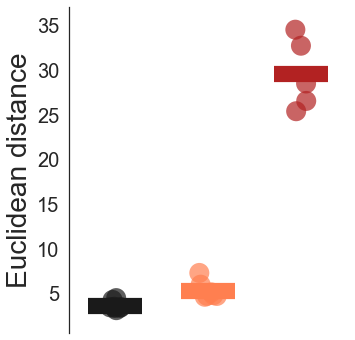

In [25]:
import seaborn as sns

from matplotlib.collections import PathCollection
from matplotlib import cm
sns.set(style="white")

colors1  = cm.Spectral_r(np.linspace(0,1,11))
colors2 = ['k','coral','firebrick']

fig, ax = plt.subplots(figsize = (5,6))
ax = sns.pointplot(x="Labels", y="data", data = df, hue = 'Labels', palette = colors2, join=True, ci=0, scale=8, markers = '_')
for artist in ax.lines:
    artist.set_zorder(10)
for artist in ax.findobj(PathCollection):
    artist.set_zorder(11)
#ax = sns.pointplot(x="Labels", y="Exponent", data=sizexdf, color = 'grey', linestyles = ["--"], ci = 0, scale=0.6)
ax = sns.stripplot(x="Labels", y="data", data=df, hue = 'Labels', palette = colors2, size = 20, jitter = True ,alpha = 0.7)

plt.yticks(size = 20)

points = ax.collections
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel(' ', size = '13')
ax.set_ylabel('Euclidean distance', size = '28')
ax.get_xaxis().set_visible(False)
#ax.set_xticklabels(['Baseline', 'Focal', 'Generalised'], size = 15)
ax.legend_.remove()
#plt.ylim(top = 2000, bottom = 0)

plt.savefig(Ffig + 'CCM_diversity_intra_distance.svg', transparent = True)
plt.show()

In [28]:
#Compare null vs empirical

adfn.stats_2samp(p5_dis, bln_dis, 0.05, 1, 'ind')

adfn.stats_2samp(p20_dis, bln_dis, 0.05, 1, 'ind')


At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 0.0   p = 0.0007300309581211239
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 0.0   p = 0.0021551792497675215


(0.0, 0.0021551792497675215)

In [31]:
adfn.mean_std('', p20_dis)

 mean = 29.503158911574435  , std = 1.7619549497242228


In [95]:
bln_dis

array([4.25630017, 3.49662552, 3.36164013, 4.46432403, 3.11500194,
       3.37522487, 3.45672716, 3.43507786])

In [205]:
mean_cross_dis(bln_v_l, p5_v_l)

array([5.15711869, 5.85668865, 5.98614323, 6.05108425, 5.97400748,
       5.75977588, 6.03168205, 5.36433652])

In [98]:
p20tobln = mean_cross_dis(bln_v_l, p20_v_l)
p20tobln

array([35.45494271, 38.20416156, 38.53452539, 36.76408191, 38.58632486,
       38.19181101, 38.54137787, 37.13012931])

In [257]:
bln_dis

array([4.25630017, 3.49662552, 3.36164013, 4.46432403, 3.11500194,
       3.37522487, 3.45672716, 3.43507786])

In [99]:
p5tobln = mean_cross_dis(bln_v_l, p5_v_l)
p5tobln

array([5.15711869, 5.85668865, 5.98614323, 6.05108425, 5.97400748,
       5.75977588, 6.03168205, 5.36433652])

In [248]:
p5top20 = mean_cross_dis(p5_v_l, p20_v_l)
p5top20

array([33.67602985, 34.92946247, 35.99882179, 36.73474634, 36.67063538,
       36.43923239, 36.37448164])

In [212]:
p5_dis

array([7.27998069, 5.10373615, 5.96543819, 4.70375917, 4.71992891,
       4.61275943, 4.79707289])

In [100]:
p20_ap = p20tobln, bln_dis
p5_ap = p5tobln, bln_dis

p20_ap, p5_ap

((array([35.45494271, 38.20416156, 38.53452539, 36.76408191, 38.58632486,
         38.19181101, 38.54137787, 37.13012931]),
  array([4.25630017, 3.49662552, 3.36164013, 4.46432403, 3.11500194,
         3.37522487, 3.45672716, 3.43507786])),
 (array([5.15711869, 5.85668865, 5.98614323, 6.05108425, 5.97400748,
         5.75977588, 6.03168205, 5.36433652]),
  array([4.25630017, 3.49662552, 3.36164013, 4.46432403, 3.11500194,
         3.37522487, 3.45672716, 3.43507786])))

In [252]:
mix_ap

(array([33.67602985, 34.92946247, 35.99882179, 36.73474634, 36.67063538,
        36.43923239, 36.37448164]),
 array([7.27998069, 5.10373615, 5.96543819, 4.70375917, 4.71992891,
        4.61275943, 4.79707289]))

In [101]:
#Compare dwell times against null models

full_list = p5_ap, p20_ap
import pandas as pd

dt = list(range(32))
cond = list(range(32))
null = list(range(32))

cond_list = ['FOC', 'GEN']
null_list = ['across', 'within']
count=0

for o in range(len(full_list)):
    for i in range(len(full_list[o])):
        for x in range(len(full_list[o][i])):
            dt[count] = full_list[o][i][x]
            cond[count] = cond_list[o]
            null[count] = null_list[i]
            count+=1
df = pd.DataFrame({"distance":dt , "condition": cond, "null": null})

In [102]:
df

,distance,condition,null
0,5.157119,FOC,across
1,5.856689,FOC,across
2,5.986143,FOC,across
3,6.051084,FOC,across
4,5.974007,FOC,across
5,5.759776,FOC,across
6,6.031682,FOC,across
7,5.364337,FOC,across
8,4.256300,FOC,within
9,3.496626,FOC,within


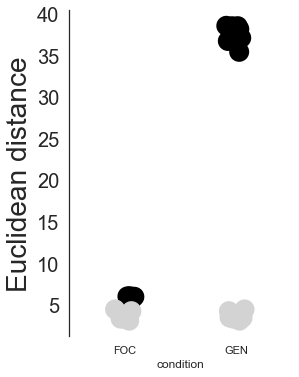

In [112]:
import seaborn as sns
from matplotlib.collections import PathCollection
from matplotlib import cm
sns.set(style="white")
colors2 = ['black','firebrick']
colors1 = ['black', 'lightgrey']
fig, ax = plt.subplots(figsize = (4,6))
#ax = sns.pointplot(x="condition", y="dwell time", data = dt_df, hue = 'condition', palette = colors2, join=True, ci=0, scale=6, markers='_')
for artist in ax.lines:
    artist.set_zorder(10)
for artist in ax.findobj(PathCollection):
    artist.set_zorder(11)
ax = sns.stripplot(x="condition", y="distance", data = df, hue = 'null', palette = colors1, size = 20, jitter = True ,alpha = 1)

ax.legend_.remove()
plt.yticks(size = 20)
ax.set_ylabel('Euclidean distance', size = '28')

points = ax.collections
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.savefig(Ffig + 'CCM_diversity_inter_distance.svg', transparent = True)

plt.show()

In [113]:
#Compare null vs empirical

adfn.stats_2samp(p5tobln, bln_dis, 0.05, 1, 'rel')

adfn.stats_2samp(p20tobln, bln_dis, 0.05, 1, 'rel')


At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
w = 0.0   p = 0.0078125
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
w = 0.0   p = 0.0078125


(0.0, 0.0078125)

In [167]:
def eigvar(data_l):
    prac = np.array(data_l).T
    ok = np.cov(prac)
    eig = np.linalg.eig(ok)
    sumeig = np.sum(np.real(eig[0]))
    return(sumeig)

In [ ]:
#BLN
l = bln_v_l
sumd_l = list(range(len(l)))
count=0
for i in l:
    sumd_l[count] = eigvar(i)
    count+=1
np.save('eigvar_BLN.npy', )



In [16]:
#CAUSAL SEIZURE NETWORK CHANGES - GRAN

#DUMB function for network vector
def ccm_net_vec(data, coord):
    #-----------------------------------------------------------------------------------

    Fzbb = '/Users/dominicburrows/Dropbox/PhD/analysis/' + 'zbrain_stacks/'
    atlasim = Fzbb + 'atlas/pajevic1.tif'
    atlasli = Fzbb + 'atlas/Pajevic_annotations.csv'
    atlaslab=pd.read_csv(atlasli, sep=',',header=None)
    lab_unq = np.unique(np.array(atlaslab[1]))

    ccm = cfn.ccm_stats(data, 'ccm')
    coord = np.load(coord, allow_pickle=True).item()['coord']

    lab_v = coord[:,3] #coord labels - coarse 


    ccm_v = np.zeros((lab_unq.shape[0]**2)) #vector representation of ccm matrix

    #Initialise heatmap
    count=0
    #Loop over all labels
    for x,l1 in enumerate(lab_unq):
        curr_row = np.where(lab_v == l1)[0]

        for y,l2 in enumerate(lab_unq):
            curr_col = np.where(lab_v == l2)[0]

            if len(curr_row) ==0 or len(curr_col) == 0:
                mean_ccm = 0


            else:
                #extend into 2 long vectors containing all cells which cover l1->l2
                #Extended row values -> repeat each element n times (n is num of column elements)
                ext_row = np.repeat(curr_row, curr_col.shape[0])

                #Extended col values -> repeat entire vector m times (m is num of row elements)
                ext_col = np.tile(curr_col, curr_row.shape[0])

                mean_ccm = np.mean(ccm[ext_row, ext_col]) #Calculate mean ccm value over all elements        

            ccm_v[count] = mean_ccm
            count+=1

    return(ccm_v)

# Seizure drivers vs passengers 

In [ ]:
# How does the regional localisation of whole brain drivers vs passengers vary? - are some regions drivers more than passengers
# How does the spatial localisation vary in the healthy vs seizure brain? 

In [31]:
# BASELINE 
data_bln_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + 'BLN' + '_run-01_t' + '*xmap*')
coord_bln_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  'BLN' + '_run' + '*1_pre-CCM.npy*')
data_bln_l, coord_bln_l

(['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-15_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5'],
 ['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_BLN_run-0

In [32]:
#Calculate difference between drivers vs passenger values
data_cause, coord_cause = cfn.ccm_cellstack(data_bln_l, coord_bln_l, 'c_to_sz')
data_effect, coord_effect = cfn.ccm_cellstack(data_bln_l, coord_bln_l, 'sz_to_c')

diff_vec = data_cause - data_effect #positive values = more seizure driver than passenger


/Users/dominicburrows/Dropbox/PhD/Analysis/my_scripts/GitHub/empirical_dynamic_modelling/CCM.py:136: H5pyDeprecationWarning: The default file mode will change to 'r' (read-only) in h5py 3.0. To suppress this warning, pass the mode you need to h5py.File(), or set the global default h5.get_config().default_file_mode, or set the environment variable H5PY_DEFAULT_READONLY=1. Available modes are: 'r', 'r+', 'w', 'w-'/'x', 'a'. See the docs for details.
  data = h5py.File(file)


In [63]:
scale = 'coarse'

#Build dict 
cause_df, cause_lab = cfn.ccm_region(data_cause, coord_cause, scale)
effect_df, effect_lab = cfn.ccm_region(data_effect, coord_effect, scale)

#Mean for each fish
cause_mean_df, cause_mean_lab = cfn.ccm_region_mean(cause_df)
effect_mean_df, effect_mean_lab = cfn.ccm_region_mean(effect_df)

# FDR comparison
sig_v, adj_p, comp_lab = cfn.ccm_fdr(cause_mean_df, effect_mean_df, 0.05, 'rel')

At least one sample is non-Gaussian - performing non-parametric test
Samples are the same
w = 18.0   p = 1.0
At least one sample is non-Gaussian - performing non-parametric test
Samples are the same
w = 13.0   p = 0.546875
At least one sample is non-Gaussian - performing non-parametric test
Samples are the same
w = 15.0   p = 0.7421875
At least one sample is non-Gaussian - performing non-parametric test
Samples are the same
w = 15.0   p = 0.7421875
At least one sample is non-Gaussian - performing non-parametric test
Samples are the same
w = 8.0   p = 0.1953125
At least one sample is non-Gaussian - performing non-parametric test
Samples are the same
w = 16.0   p = 0.84375


/Users/dominicburrows/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1604: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  "anyway, n=%i" % int(n))


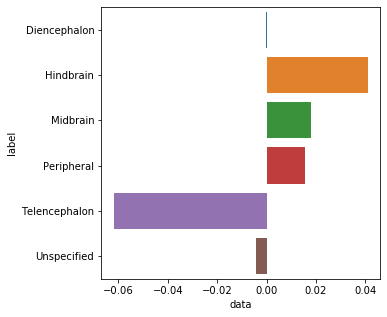

In [74]:
# BASELINE vs BASELINE

shift = 0.35 #coarse = 0.05, gran = 0.35
diff_df = cfn.ccm_diff_dict(effect_mean_df, cause_mean_df)

fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(y="label", x="data", data=diff_df)

for s,name in enumerate(np.array(diff_df['label'])):
    if name in comp_lab[sig_v]:
        plt.text(x=0, y=s+shift, s='*', size = 30) 
plt.show()

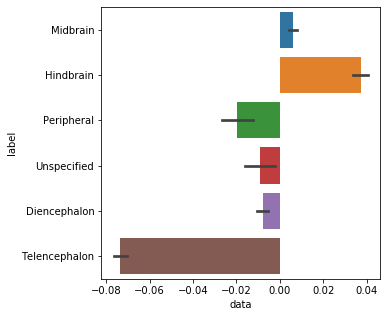

In [67]:
#Neurons pooled across fish
df, lab = cfn.ccm_region(diff_vec, coord_cause, 'coarse')

shift = 0.35 #coarse = 0.05, gran = 0.35

#Visualise single dataset bar plot
fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(y="label", x="data", data=df)
plt.show()

In [ ]:
scale = 'gran'

#Build dict 
cause_df, cause_lab = cfn.ccm_region(data_cause, coord_cause, scale)
effect_df, effect_lab = cfn.ccm_region(data_effect, coord_effect, scale)

#Mean for each fish
cause_mean_df, cause_mean_lab = cfn.ccm_region_mean(cause_df)
effect_mean_df, effect_mean_lab = cfn.ccm_region_mean(effect_df)

# FDR comparison
sig_v, adj_p, comp_lab = cfn.ccm_fdr(cause_mean_df, effect_mean_df, 0.05, 'rel')

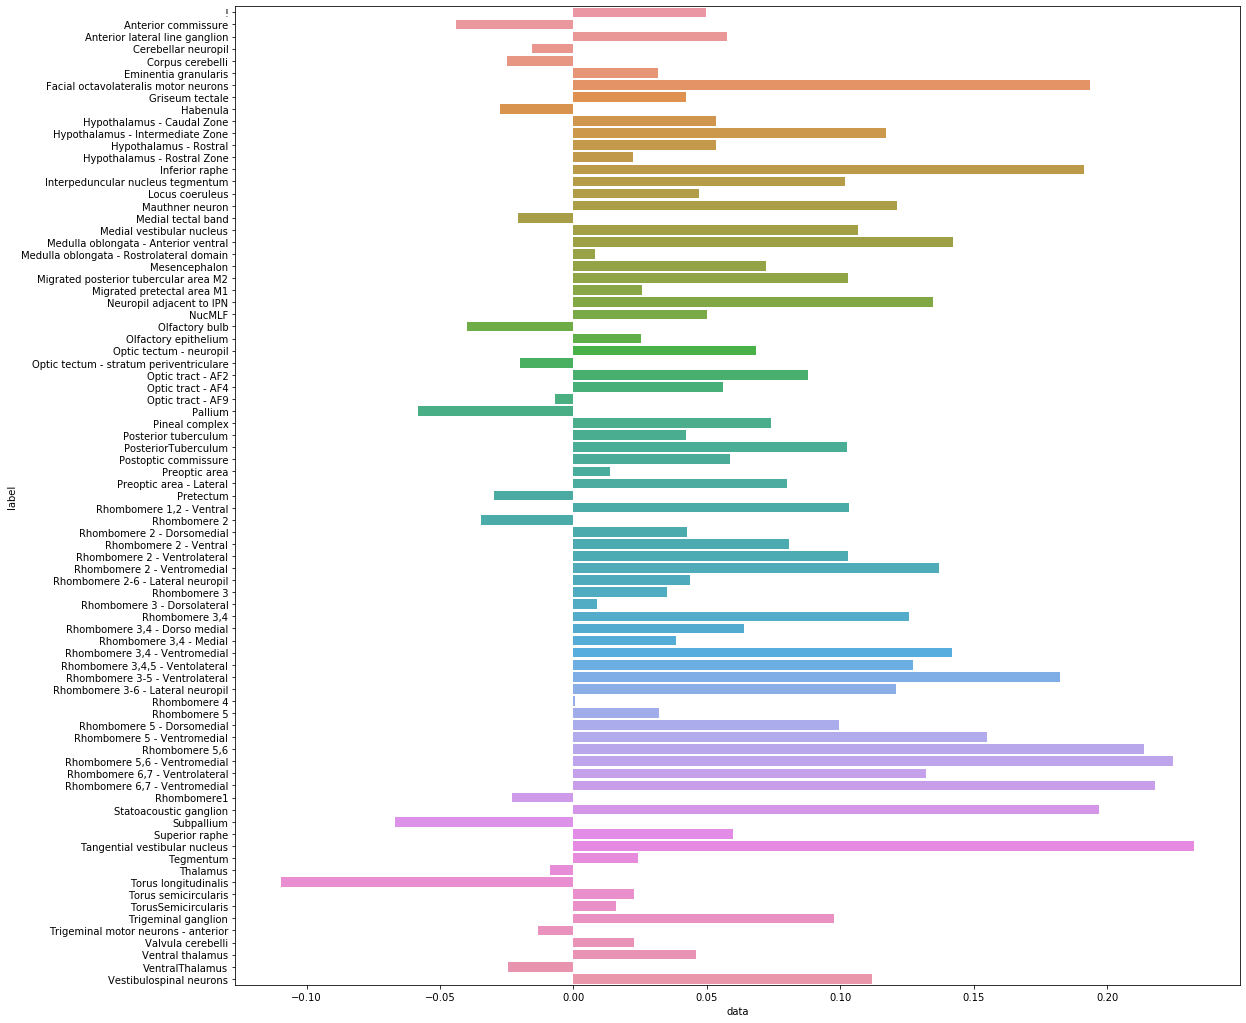

In [76]:
# BASELINE -> BASELIN

shift = 0.05 #coarse = 0.05, gran = 0.5
diff_df = cfn.ccm_diff_dict(effect_mean_df, cause_mean_df)

fig, ax = plt.subplots(figsize = ((18,18)))
ax = sns.barplot(y="label", x="data", data=diff_df)

for s,name in enumerate(np.array(diff_df['label'])):
    if name in comp_lab[sig_v]:
        plt.text(x=0, y=s+shift, s='*', size = 30) 
plt.show()


# Whole brain activity drivers

In [ ]:
# Different brain regions/populations contribute to whole brain activity at rest
# How does the contribution of brain regions to whole brain activity change during the seizure?

In [139]:
# BASELINE -> FOCAL SEIZURE
data_bln_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + 'BLN' + '_run-01_t' + '*xmap*')
coord_bln_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  'BLN' + '_run' + '*1_pre-CCM.npy*')
data_p5_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + 'PTZ05' + '_run-01_t' + '*xmap*')
coord_p5_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  'PTZ05' + '_run' + '*1_pre-CCM.npy*')
data_bln_l, coord_bln_l, data_p5_l, coord_p5_l

(['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-15_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5'],
 ['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_BLN_run-0

In [ ]:
datatype = 'c_to_sz'

#Combine multiple fish brains together
data_bln, coord_bln = cfn.ccm_cellstack(data_bln_l, coord_bln_l, datatype)
data_p5, coord_p5 = cfn.ccm_cellstack(data_p5_l, coord_p5_l, datatype)


In [140]:
datatype = 'c_to_sz'

#Combine multiple fish brains together
data_bln, coord_bln = cfn.ccm_cellstack(data_bln_l, coord_bln_l, datatype)
data_p5, coord_p5 = cfn.ccm_cellstack(data_p5_l, coord_p5_l, datatype)


In [159]:
scale = 'coarse'

#Build dict 
bln_df, bln_lab = cfn.ccm_region(data_bln, coord_bln, scale)
sz_df, sz_lab = cfn.ccm_region(data_p5, coord_p5, scale)

#Mean for each fish
bln_mean_df, bln_mean_lab = cfn.ccm_region_mean(bln_df)
sz_mean_df, sz_mean_lab = cfn.ccm_region_mean(sz_df)

# FDR comparison
sig_v, adj_p, comp_lab = cfn.ccm_fdr(bln_mean_df, sz_mean_df, 0.05, 'rel')

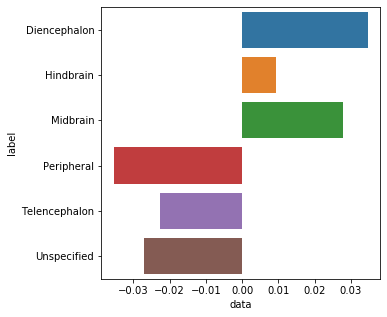

In [163]:
# BASELINE -> FOCAL SEIZURE

shift = 0.35 #coarse = 0.05, gran = 0.35
diff_df = cfn.ccm_diff_dict(bln_mean_df, sz_mean_df)

fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(y="label", x="data", data=diff_df)

for s,name in enumerate(np.array(diff_df['label'])):
    if name in comp_lab[sig_v]:
        plt.text(x=0, y=s+shift, s='*', size = 30) 
plt.show()

In [ ]:
scale = 'gran'

#Build dict 
bln_df, bln_lab = cfn.ccm_region(data_bln, coord_bln, scale)
sz_df, sz_lab = cfn.ccm_region(data_p5, coord_p5, scale)

#Mean for each fish
bln_mean_df, bln_mean_lab = cfn.ccm_region_mean(bln_df)
sz_mean_df, sz_mean_lab = cfn.ccm_region_mean(sz_df)

# FDR comparison
sig_v, adj_p, comp_lab = cfn.ccm_fdr(bln_mean_df, sz_mean_df, 0.05, 'rel')

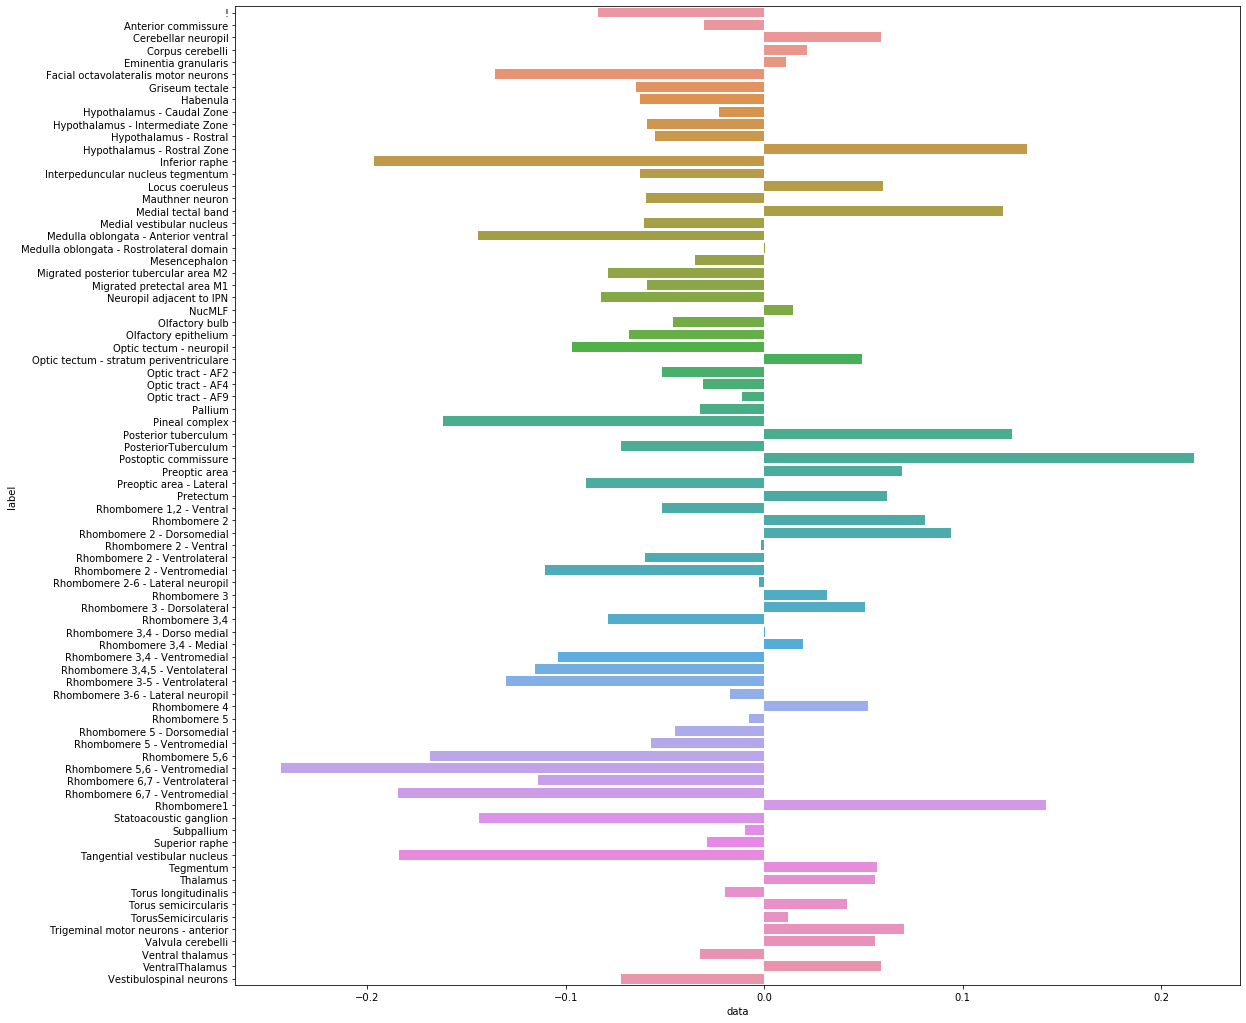

In [192]:
# BASELINE -> FOCAL SEIZURE

shift = 0.05 #coarse = 0.05, gran = 0.5
diff_df = cfn.ccm_diff_dict(bln_mean_df, sz_mean_df)

fig, ax = plt.subplots(figsize = ((18,18)))
ax = sns.barplot(y="label", x="data", data=diff_df)

for s,name in enumerate(np.array(diff_df['label'])):
    if name in comp_lab[sig_v]:
        plt.text(x=0, y=s+shift, s='*', size = 30) 
plt.show()


In [150]:
# BASELINE -> GEN SEIZURE
data_bln_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + 'BLN' + '_run-01_t' + '*xmap*')
coord_bln_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  'BLN' + '_run' + '*1_pre-CCM.npy*')
data_p20_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + 'PTZ20' + '_run-01_t' + '*xmap*')
coord_p20_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  'PTZ20' + '_run' + '*1_pre-CCM.npy*')
data_bln_l, coord_bln_l, data_p20_l, coord_p20_l

(['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-15_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5'],
 ['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_BLN_run-0

In [151]:
datatype = 'c_to_sz'

#Combine multiple fish brains together
#data_bln, coord_bln = cfn.ccm_cellstack(data_bln_l, coord_bln_l, datatype)
data_p20, coord_p20 = cfn.ccm_cellstack(data_p20_l, coord_p20_l, datatype)


/Users/dominicburrows/Dropbox/PhD/Analysis/my_scripts/GitHub/empirical_dynamic_modelling/CCM.py:136: H5pyDeprecationWarning: The default file mode will change to 'r' (read-only) in h5py 3.0. To suppress this warning, pass the mode you need to h5py.File(), or set the global default h5.get_config().default_file_mode, or set the environment variable H5PY_DEFAULT_READONLY=1. Available modes are: 'r', 'r+', 'w', 'w-'/'x', 'a'. See the docs for details.
  data = h5py.File(file)


In [196]:
scale = 'coarse'

#Build dict 
bln_df, bln_lab = cfn.ccm_region(data_bln, coord_bln, scale)
sz_df, sz_lab = cfn.ccm_region(data_p20, coord_p20, scale)

#Mean for each fish
bln_mean_df, bln_mean_lab = cfn.ccm_region_mean(bln_df)
sz_mean_df, sz_mean_lab = cfn.ccm_region_mean(sz_df)

# FDR comparison
sig_v, adj_p, comp_lab = cfn.ccm_fdr(bln_mean_df, sz_mean_df, 0.05, 'ind')

At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 2.0   p = 0.005207497329531634
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 8.0   p = 0.046146169517036595
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 6.0   p = 0.024066198109790972
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 8.0   p = 0.046146169517036595
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 1.0   p = 0.0033832500175298174
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 1.0   p = 0.0033832500175298174


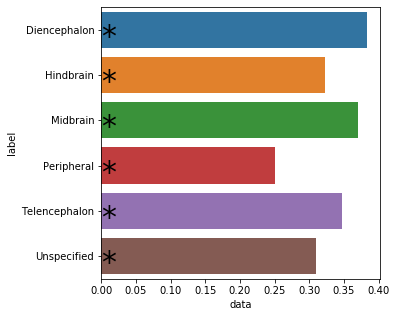

In [211]:
# BASELINE -> GEN SEIZURE

shift = 0.35 #coarse = 0.05, gran = 0.35
diff_df = cfn.ccm_diff_dict(bln_mean_df, sz_mean_df)

fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(y="label", x="data", data=diff_df)

for s,name in enumerate(np.array(diff_df['label'])):
    if name in comp_lab[sig_v]:
        plt.text(x=0, y=s+shift, s='*', size = 30) 
plt.show()

In [ ]:
scale = 'gran'

#Build dict 
bln_df, bln_lab = cfn.ccm_region(data_bln, coord_bln, scale)
sz_df, sz_lab = cfn.ccm_region(data_p20, coord_p20, scale)

#Mean for each fish
bln_mean_df, bln_mean_lab = cfn.ccm_region_mean(bln_df)
sz_mean_df, sz_mean_lab = cfn.ccm_region_mean(sz_df)

# FDR comparison
sig_v, adj_p, comp_lab = cfn.ccm_fdr(bln_mean_df, sz_mean_df, 0.05, 'ind')

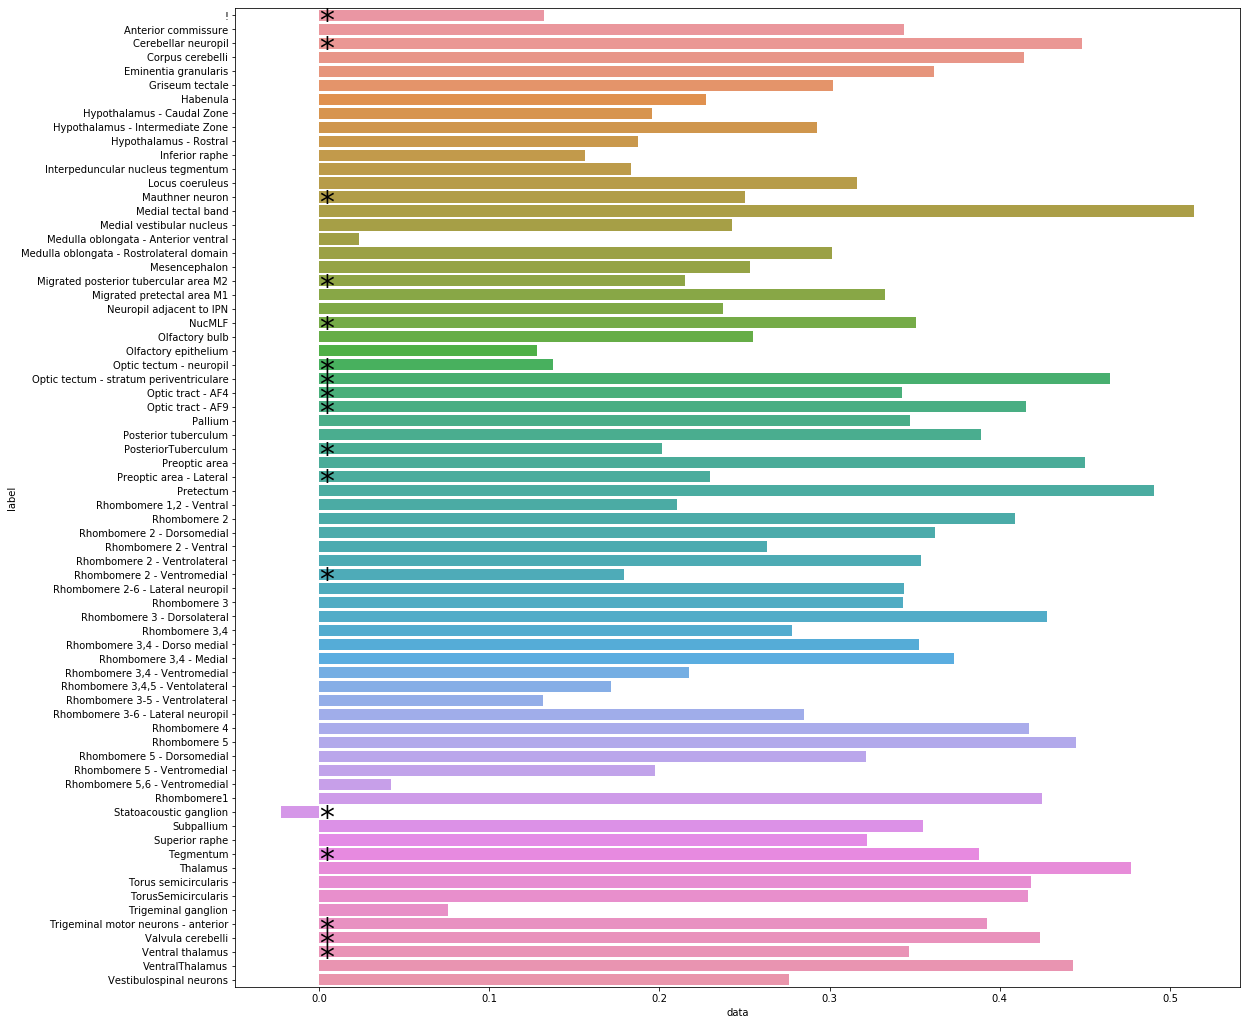

In [215]:
# BASELINE -> GEN SEIZURE

shift = 0.05 #coarse = 0.05, gran = 0.3
diff_df = cfn.ccm_diff_dict(bln_mean_df, sz_mean_df)

fig, ax = plt.subplots(figsize = ((18,18)))
ax = sns.barplot(y="label", x="data", data=diff_df)

for s,name in enumerate(np.array(diff_df['label'])):
    if name in comp_lab[sig_v]:
        plt.text(x=0, y=s+shift, s='*', size = 30) 
plt.show()


In [ ]:
# CELLS DRIVING BASELINE ACTIVITY
cond_list = 'BLN', 'PTZ05', 'PTZ20'
cond = cond_list[0]
print(cond)

data_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + cond + '_run-01_t' + '*xmap*')
coord_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  cond + '_run' + '*1_pre-CCM.npy*')
data_l, coord_l

In [92]:
#BLN
data, coord = cfn.ccm_cellstack(data_l, coord_l, 'c_to_sz')
data.shape, coord.shape

/Users/dominicburrows/Dropbox/PhD/Analysis/my_scripts/GitHub/empirical_dynamic_modelling/CCM.py:136: H5pyDeprecationWarning: The default file mode will change to 'r' (read-only) in h5py 3.0. To suppress this warning, pass the mode you need to h5py.File(), or set the global default h5.get_config().default_file_mode, or set the environment variable H5PY_DEFAULT_READONLY=1. Available modes are: 'r', 'r+', 'w', 'w-'/'x', 'a'. See the docs for details.
  data = h5py.File(file)


((78499,), (78499, 6))

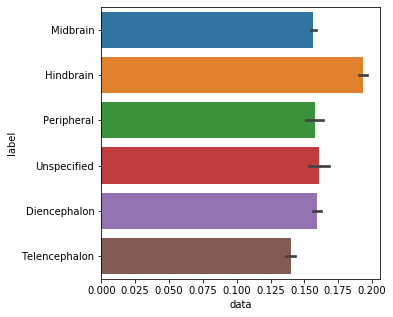

In [98]:
#Neurons pooled across fish
df, lab = cfn.ccm_region(data, coord, 'coarse')

#Visualise single dataset bar plot
fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(y="label", x="data", data=df)
plt.show()

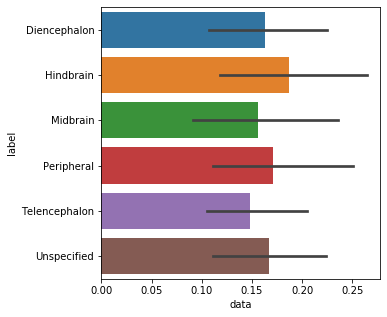

In [96]:
#Mean for each fish
mean_df, lab = cfn.ccm_region_mean(df)

#Visualise single dataset bar plot
fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(y="label", x="data", data=mean_df)
plt.show()

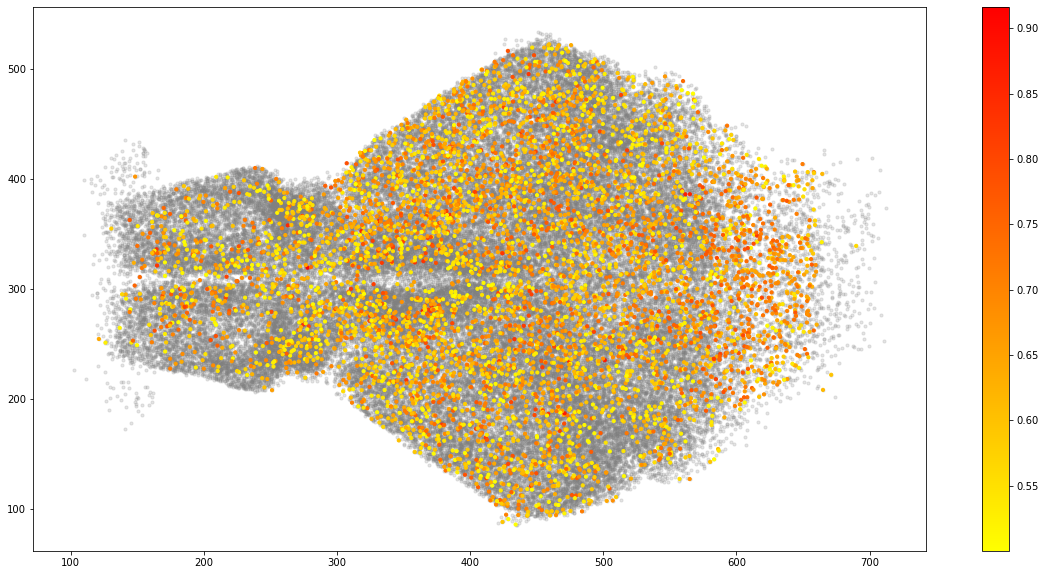

In [103]:
#Visualise fish
cfn.ccm_cellplot(df, 0.5, '', 0.05)

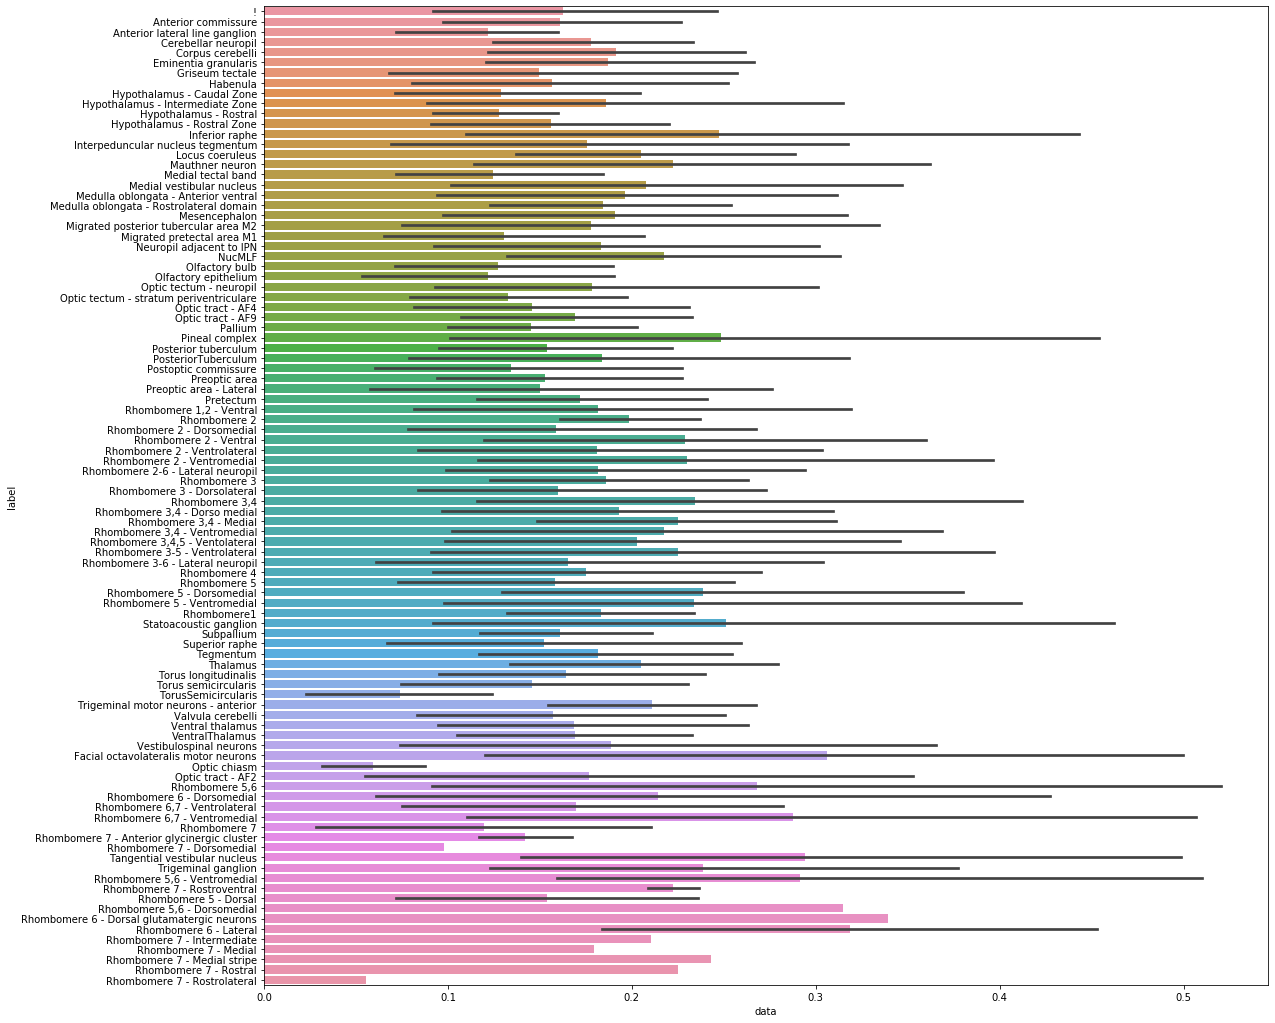

In [97]:
#Neurons pooled across fish
df, lab = cfn.ccm_region(data, coord, 'gran')

#Mean for each fish
mean_df, lab = cfn.ccm_region_mean(df)

#Visualise single dataset bar plot
fig, ax = plt.subplots(figsize = ((18,18)))
ax = sns.barplot(y="label", x="data", data=mean_df)
plt.show()

In [74]:
# CELLS DRIVING FOCAL SEIZURES
cond_list = 'BLN', 'PTZ05', 'PTZ20'
cond = cond_list[1]
print(cond)

data_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + cond + '_run-01_t' + '*xmap*')
coord_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  cond + '_run' + '*1_pre-CCM.npy*')
data_l, coord_l

PTZ05


(['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-15_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5'],
 ['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-14_2p

In [75]:
#PTZ05
data, coord = cfn.ccm_cellstack(data_l, coord_l, 'c_to_sz')
data.shape, coord.shape

/Users/dominicburrows/Dropbox/PhD/Analysis/my_scripts/GitHub/empirical_dynamic_modelling/CCM.py:136: H5pyDeprecationWarning: The default file mode will change to 'r' (read-only) in h5py 3.0. To suppress this warning, pass the mode you need to h5py.File(), or set the global default h5.get_config().default_file_mode, or set the environment variable H5PY_DEFAULT_READONLY=1. Available modes are: 'r', 'r+', 'w', 'w-'/'x', 'a'. See the docs for details.
  data = h5py.File(file)


((89564,), (89564, 6))

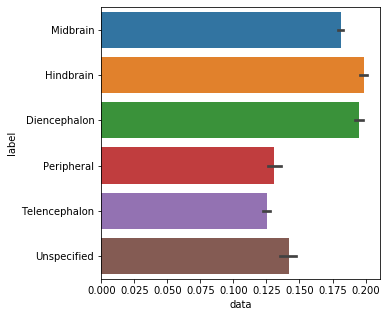

In [82]:
#Neurons pooled across fish
df, lab = cfn.ccm_region(data, coord, 'coarse')

#Visualise single dataset bar plot
fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(y="label", x="data", data=df)
plt.show()

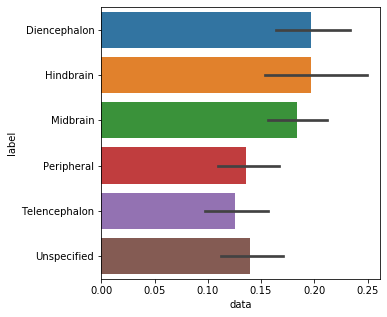

In [77]:
#Mean for each fish
mean_df, lab = cfn.ccm_region_mean(df)

#Visualise single dataset bar plot
fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(y="label", x="data", data=mean_df)
plt.show()

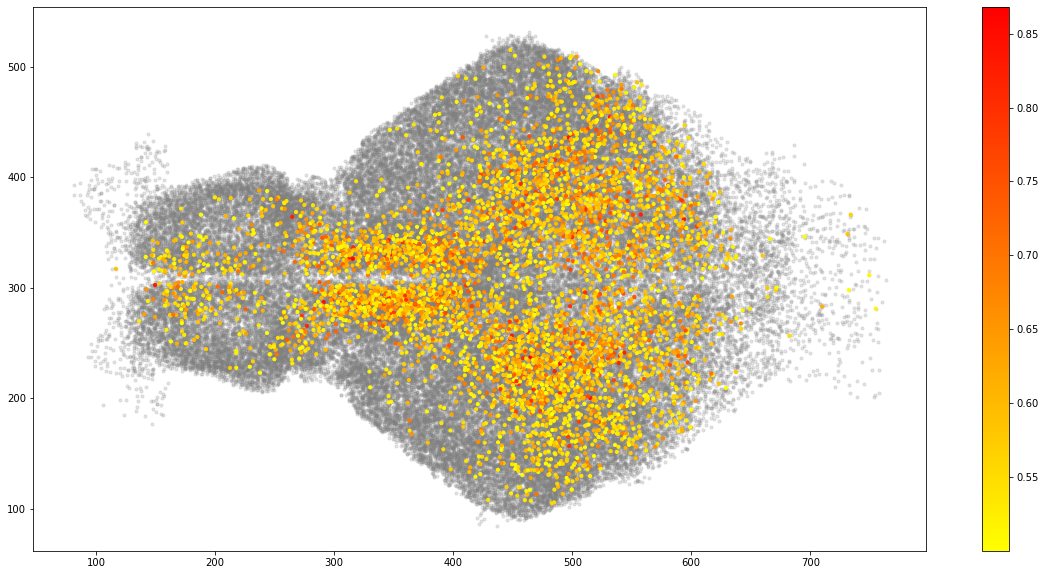

In [85]:
#Visualise fish
cfn.ccm_cellplot(df, 0.5, '')

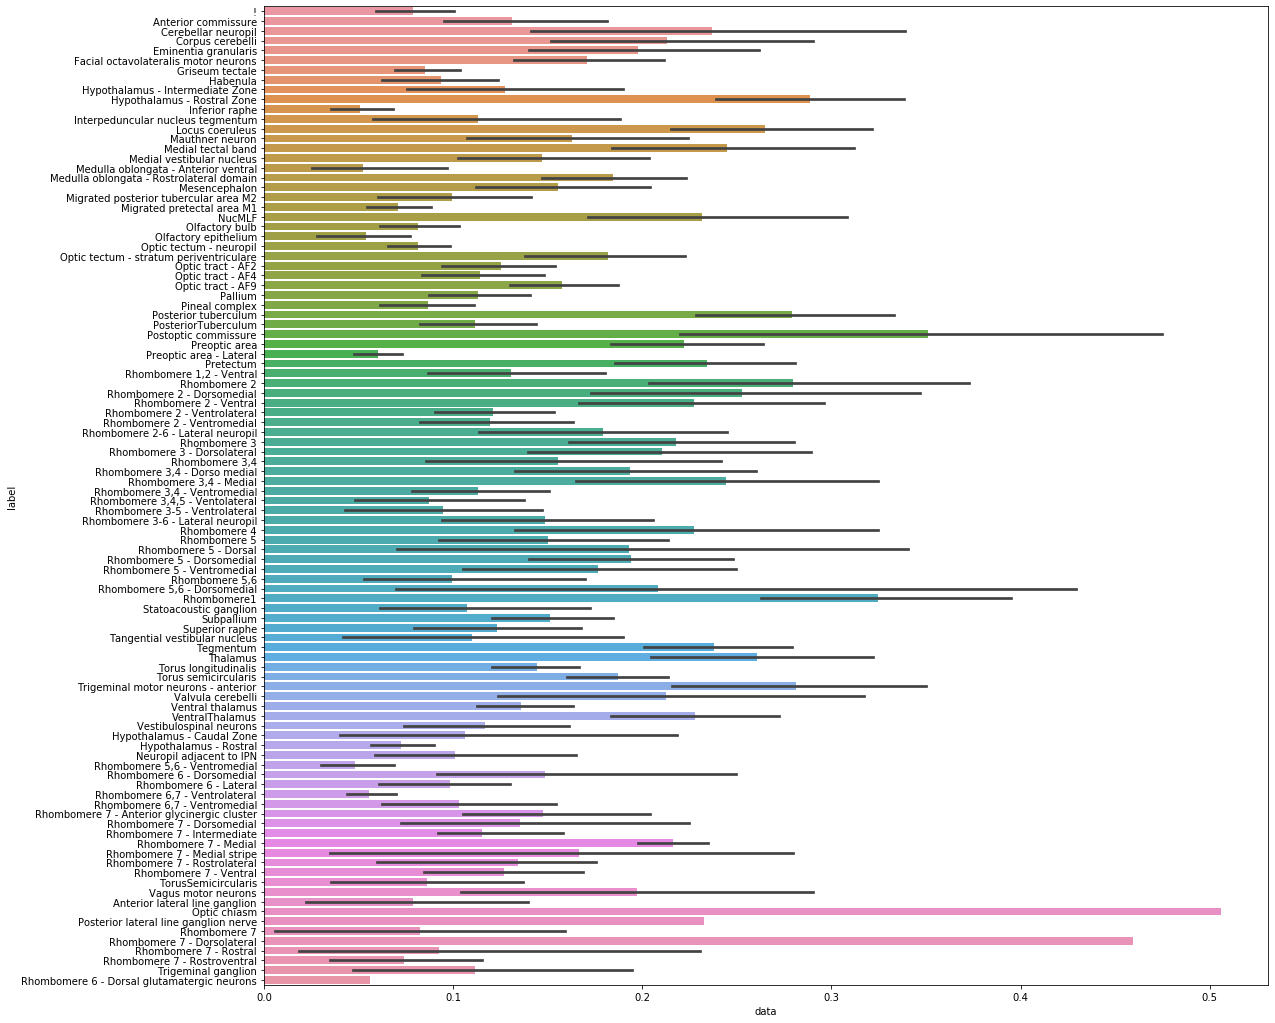

In [86]:
#Neurons pooled across fish
df, lab = cfn.ccm_region(data, coord, 'gran')

#Mean for each fish
mean_df, lab = cfn.ccm_region_mean(df)

#Visualise single dataset bar plot
fig, ax = plt.subplots(figsize = ((18,18)))
ax = sns.barplot(y="label", x="data", data=mean_df)
plt.show()

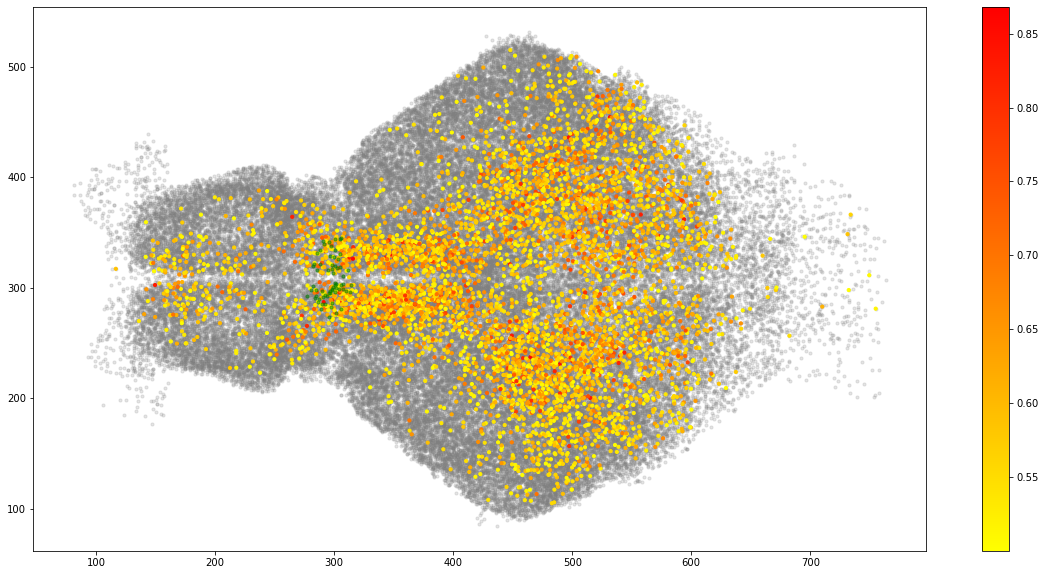

In [90]:
%autoreload
#Visualise fish
cfn.ccm_cellplot(df, 0.5, 'Postoptic commissure', 0.5)

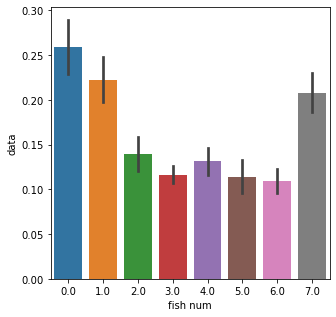

In [81]:
#Mean values across each fish
mean_df, lab = cfn.ccm_region_mean(df)

#Visualise single dataset bar plot
fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(x="fish num", y="data", data=mean_df)
plt.show()

In [2]:
# CELLS DRIVING GENERALISED SEIZURES
cond_list = 'BLN', 'PTZ05', 'PTZ20'
cond = cond_list[2]
print(cond)

data_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + cond + '_run-01_t' + '*xmap*')
coord_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  cond + '_run' + '*1_pre-CCM.npy*')
data_l, coord_l

PTZ20


(['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5'],
 ['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy'])

In [3]:
#PTZ20
data, coord = cfn.ccm_cellstack(data_l, coord_l, 'c_to_sz')
data.shape, coord.shape

/Users/dominicburrows/Dropbox/PhD/Analysis/my_scripts/GitHub/empirical_dynamic_modelling/CCM.py:136: H5pyDeprecationWarning: The default file mode will change to 'r' (read-only) in h5py 3.0. To suppress this warning, pass the mode you need to h5py.File(), or set the global default h5.get_config().default_file_mode, or set the environment variable H5PY_DEFAULT_READONLY=1. Available modes are: 'r', 'r+', 'w', 'w-'/'x', 'a'. See the docs for details.
  data = h5py.File(file)


((44389,), (44389, 6))

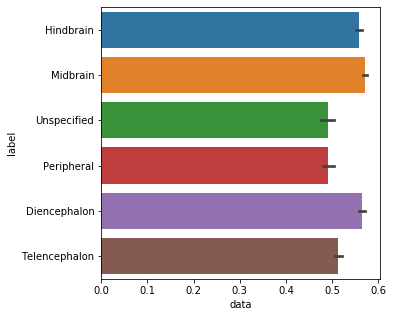

In [72]:
#Neurons pooled across fish
df, lab = cfn.ccm_region(data, coord, 'coarse')

#Visualise single dataset bar plot
fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(y="label", x="data", data=df)
plt.show()

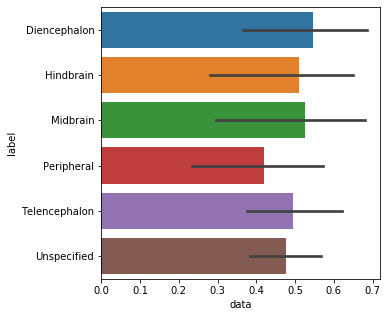

In [45]:
#Mean for each fish
mean_df, lab = cfn.ccm_region_mean(df)

#Visualise single dataset bar plot
fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(y="label", x="data", data=mean_df)
plt.show()

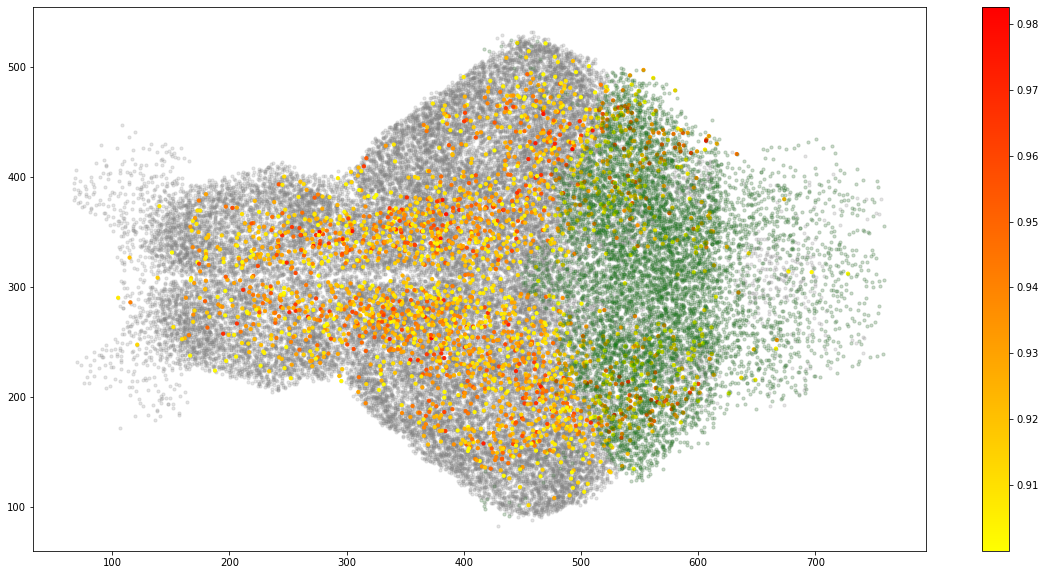

In [73]:
#Visualise fish
cfn.ccm_cellplot(df, 0.9, 'Hindbrain')

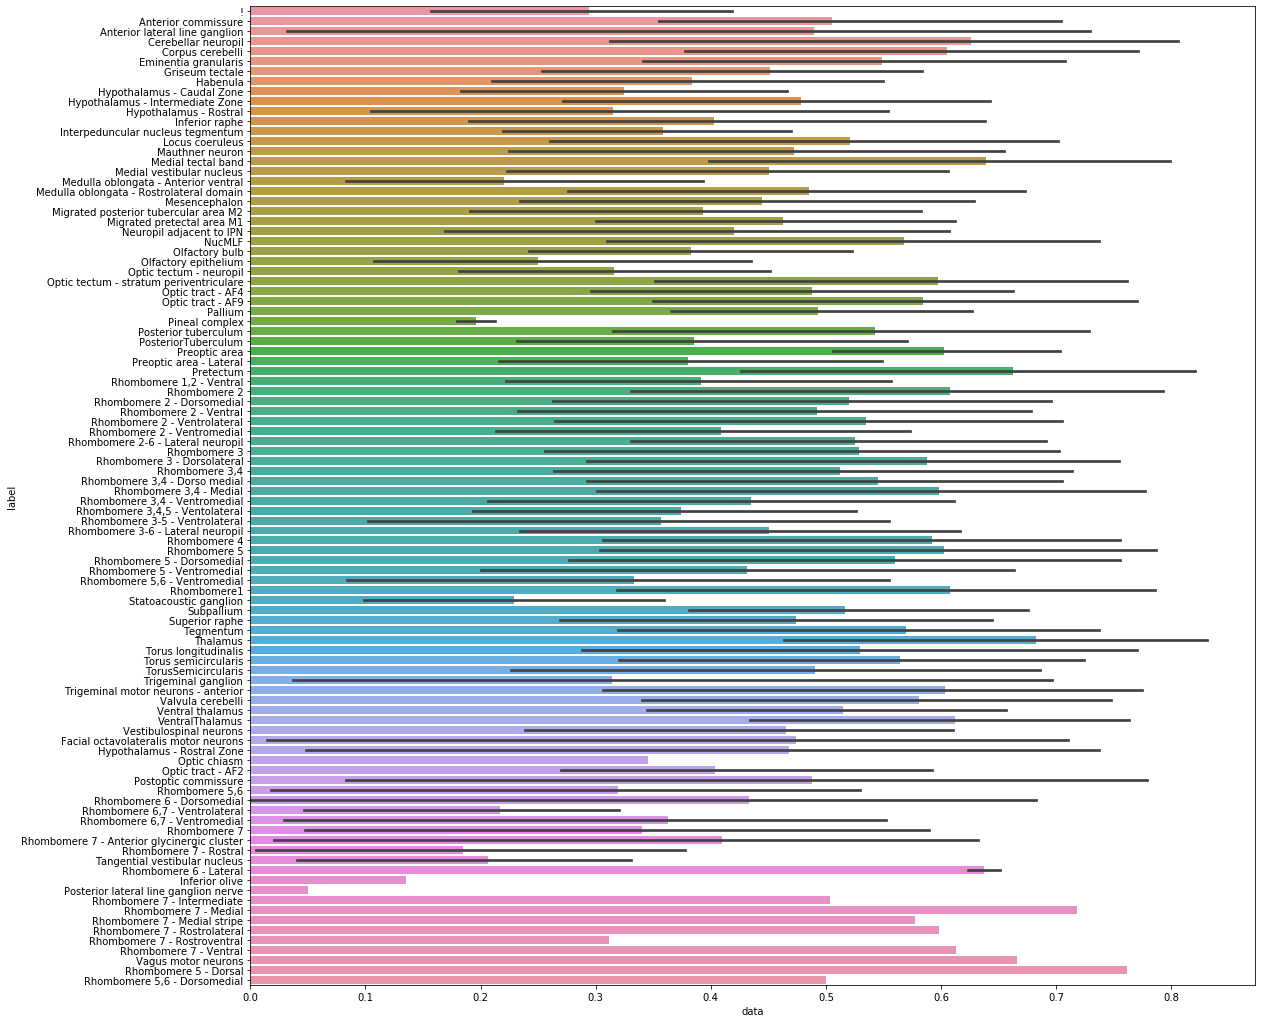

In [66]:
#Neurons pooled across fish
df, lab = cfn.ccm_region(data, coord, 'gran')

#Mean for each fish
mean_df, lab = cfn.ccm_region_mean(df)

#Visualise single dataset bar plot
fig, ax = plt.subplots(figsize = ((18,18)))
ax = sns.barplot(y="label", x="data", data=mean_df)
plt.show()

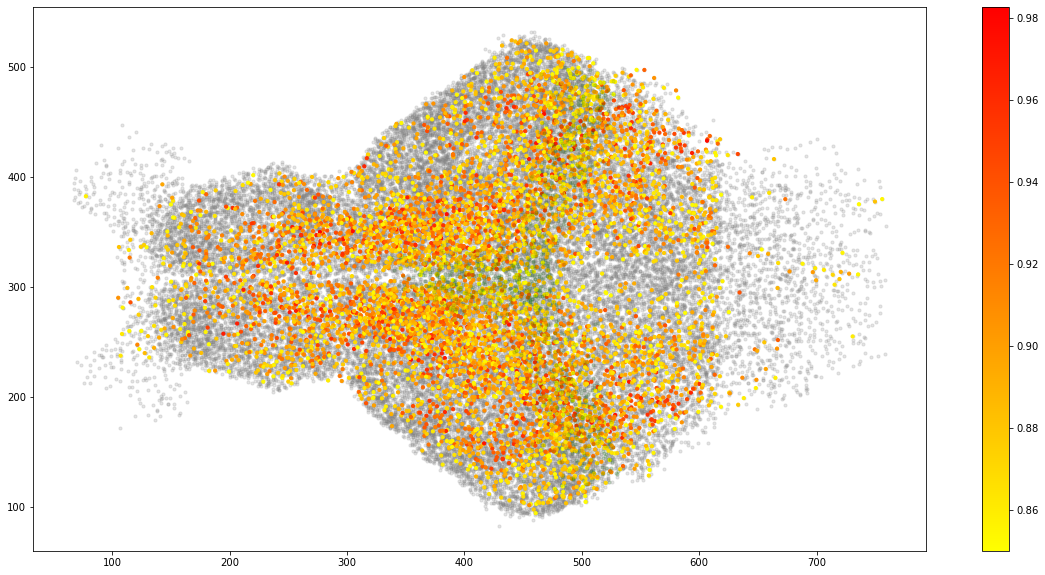

In [70]:
#Visualise fish
cfn.ccm_cellplot(df, 0.85, 'Medial tectal band')

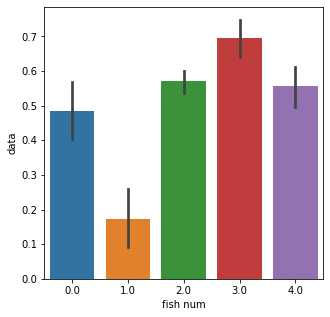

In [37]:
#Mean values across each fish
mean_df, lab = cfn.ccm_region_mean(df)

#Visualise single dataset bar plot
fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(x="fish num", y="data", data=mean_df)
plt.show()

# Whole brain activity passengers


In [171]:
# Different brain regions/populations are driven by whole brain activity at rest
# How does the effect of whole brain activity on different brain regions change during the seizure?

In [9]:
# BASELINE -> FOCAL SEIZURE
data_bln_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + 'BLN' + '_run-01_t' + '*xmap*')
coord_bln_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  'BLN' + '_run' + '*1_pre-CCM.npy*')
data_p5_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + 'PTZ05' + '_run-01_t' + '*xmap*')
coord_p5_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  'PTZ05' + '_run' + '*1_pre-CCM.npy*')
data_bln_l, coord_bln_l, data_p5_l, coord_p5_l

(['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-15_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5'],
 ['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_BLN_run-0

In [10]:
datatype = 'sz_to_c'

#Combine multiple fish brains together
data_bln, coord_bln = cfn.ccm_cellstack(data_bln_l, coord_bln_l, datatype)
data_p5, coord_p5 = cfn.ccm_cellstack(data_p5_l, coord_p5_l, datatype)


/Users/dominicburrows/Dropbox/PhD/Analysis/my_scripts/GitHub/empirical_dynamic_modelling/CCM.py:136: H5pyDeprecationWarning: The default file mode will change to 'r' (read-only) in h5py 3.0. To suppress this warning, pass the mode you need to h5py.File(), or set the global default h5.get_config().default_file_mode, or set the environment variable H5PY_DEFAULT_READONLY=1. Available modes are: 'r', 'r+', 'w', 'w-'/'x', 'a'. See the docs for details.
  data = h5py.File(file)


In [11]:
scale = 'coarse'

#Build dict 
bln_df, bln_lab = cfn.ccm_region(data_bln, coord_bln, scale)
sz_df, sz_lab = cfn.ccm_region(data_p5, coord_p5, scale)

#Mean for each fish
bln_mean_df, bln_mean_lab = cfn.ccm_region_mean(bln_df)
sz_mean_df, sz_mean_lab = cfn.ccm_region_mean(sz_df)

# FDR comparison
sig_v, adj_p, comp_lab = cfn.ccm_fdr(bln_mean_df, sz_mean_df, 0.05, 'rel')

At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
w = 0.0   p = 0.0078125
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
w = 0.0   p = 0.0078125
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
w = 0.0   p = 0.0078125
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
w = 0.0   p = 0.0078125
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
w = 0.0   p = 0.0078125
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
w = 0.0   p = 0.0078125


/Users/dominicburrows/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1604: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  "anyway, n=%i" % int(n))


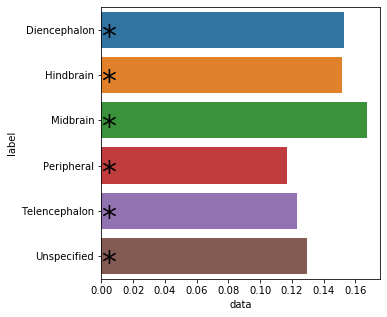

In [12]:

# BASELINE -> FOCAL SEIZURE

shift = 0.35 #coarse = 0.05, gran = 0.35
diff_df = cfn.ccm_diff_dict(bln_mean_df, sz_mean_df)

fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(y="label", x="data", data=diff_df)

for s,name in enumerate(np.array(diff_df['label'])):
    if name in comp_lab[sig_v]:
        plt.text(x=0, y=s+shift, s='*', size = 30) 
plt.show()

In [ ]:
scale = 'gran'

#Build dict 
bln_df, bln_lab = cfn.ccm_region(data_bln, coord_bln, scale)
sz_df, sz_lab = cfn.ccm_region(data_p5, coord_p5, scale)

#Mean for each fish
bln_mean_df, bln_mean_lab = cfn.ccm_region_mean(bln_df)
sz_mean_df, sz_mean_lab = cfn.ccm_region_mean(sz_df)

# FDR comparison
sig_v, adj_p, comp_lab = cfn.ccm_fdr(bln_mean_df, sz_mean_df, 0.05, 'rel')


In [17]:
sig_v

array([ True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

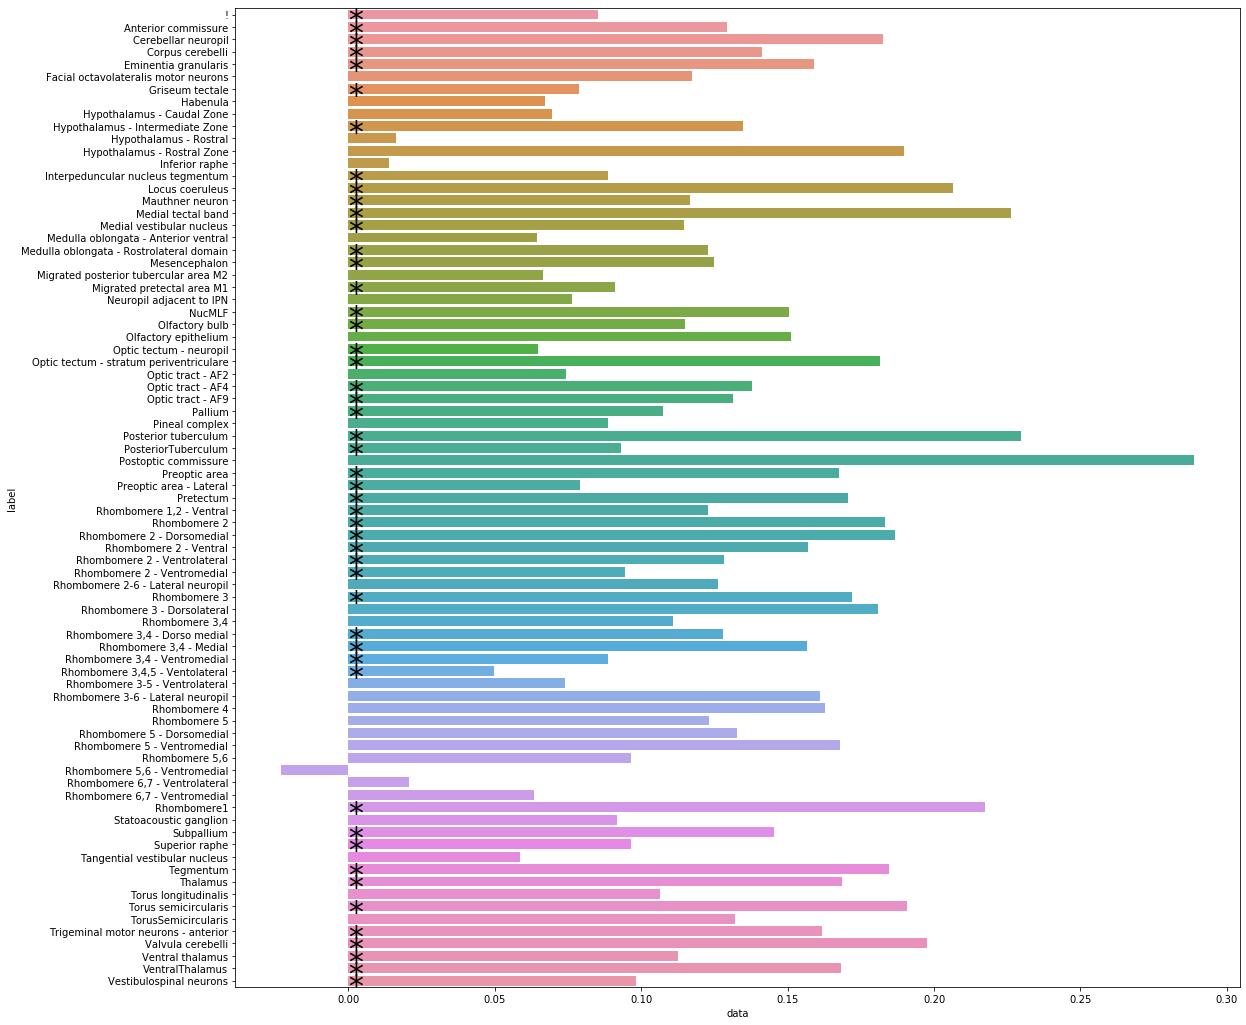

In [21]:
# BASELINE -> FOCAL SEIZURE

shift = 1.2 #coarse = 0.05, gran = 0.5
diff_df = cfn.ccm_diff_dict(bln_mean_df, sz_mean_df)

fig, ax = plt.subplots(figsize = ((18,18)))
ax = sns.barplot(y="label", x="data", data=diff_df)

for s,name in enumerate(np.array(diff_df['label'])):
    if name in comp_lab[sig_v]:
        plt.text(x=0, y=s+shift, s='*', size = 30) 
plt.show()


In [22]:
# BASELINE -> GEN SEIZURE
data_bln_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + 'BLN' + '_run-01_t' + '*xmap*')
coord_bln_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  'BLN' + '_run' + '*1_pre-CCM.npy*')
data_p20_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + 'PTZ20' + '_run-01_t' + '*xmap*')
coord_p20_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  'PTZ20' + '_run' + '*1_pre-CCM.npy*')
data_bln_l, coord_bln_l, data_p20_l, coord_p20_l


(['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-15_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5'],
 ['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_BLN_run-0

In [24]:
datatype = 'sz_to_c'

#Combine multiple fish brains together
#data_bln, coord_bln = cfn.ccm_cellstack(data_bln_l, coord_bln_l, datatype)
data_p20, coord_p20 = cfn.ccm_cellstack(data_p20_l, coord_p20_l, datatype)

In [25]:
scale = 'coarse'

#Build dict 
bln_df, bln_lab = cfn.ccm_region(data_bln, coord_bln, scale)
sz_df, sz_lab = cfn.ccm_region(data_p20, coord_p20, scale)

#Mean for each fish
bln_mean_df, bln_mean_lab = cfn.ccm_region_mean(bln_df)
sz_mean_df, sz_mean_lab = cfn.ccm_region_mean(sz_df)

# FDR comparison
sig_v, adj_p, comp_lab = cfn.ccm_fdr(bln_mean_df, sz_mean_df, 0.05, 'ind')



At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 1.0   p = 0.0033832500175298174
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 8.0   p = 0.046146169517036595
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 1.0   p = 0.0033832500175298174
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 4.0   p = 0.011635146004975378
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 0.0   p = 0.0021551792497675215
At least one sample is non-Gaussian - performing non-parametric test
Samples are significantly different
U = 0.0   p = 0.0021551792497675215


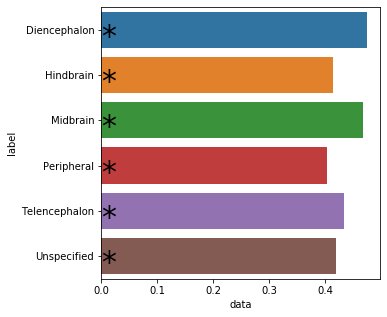

In [26]:
# BASELINE -> GEN SEIZURE

shift = 0.35 #coarse = 0.05, gran = 0.35
diff_df = cfn.ccm_diff_dict(bln_mean_df, sz_mean_df)

fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(y="label", x="data", data=diff_df)

for s,name in enumerate(np.array(diff_df['label'])):
    if name in comp_lab[sig_v]:
        plt.text(x=0, y=s+shift, s='*', size = 30) 
plt.show()

In [ ]:
scale = 'gran'

#Build dict 
bln_df, bln_lab = cfn.ccm_region(data_bln, coord_bln, scale)
sz_df, sz_lab = cfn.ccm_region(data_p20, coord_p20, scale)

#Mean for each fish
bln_mean_df, bln_mean_lab = cfn.ccm_region_mean(bln_df)
sz_mean_df, sz_mean_lab = cfn.ccm_region_mean(sz_df)

# FDR comparison
sig_v, adj_p, comp_lab = cfn.ccm_fdr(bln_mean_df, sz_mean_df, 0.05, 'ind')

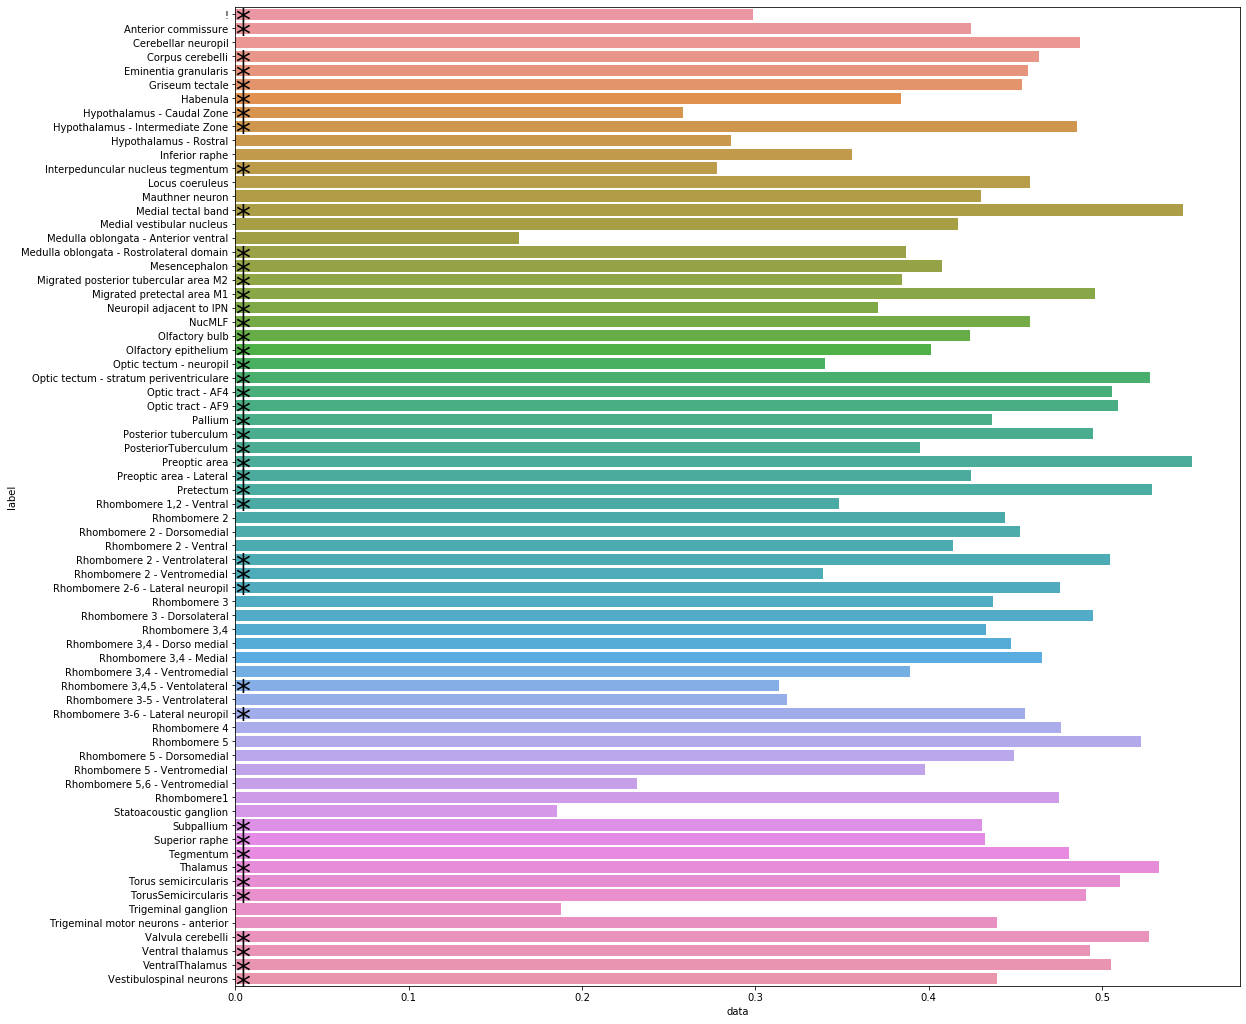

In [30]:

# BASELINE -> GEN SEIZURE

shift = 1.1 #coarse = 0.05, gran = 0.3
diff_df = cfn.ccm_diff_dict(bln_mean_df, sz_mean_df)

fig, ax = plt.subplots(figsize = ((18,18)))
ax = sns.barplot(y="label", x="data", data=diff_df)

for s,name in enumerate(np.array(diff_df['label'])):
    if name in comp_lab[sig_v]:
        plt.text(x=0, y=s+shift, s='*', size = 30) 
plt.show()


In [223]:
# CELLS DRIVEN BY BASELINE ACTIVITY
cond_list = 'BLN', 'PTZ05', 'PTZ20'
cond = cond_list[0]
print(cond)

data_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + cond + '_run-01_t' + '*xmap*')
coord_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  cond + '_run' + '*1_pre-CCM.npy*')
data_l, coord_l

BLN


(['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-15_2photon_sess-01-6dpf_BLN_run-01_trace_CCMxmap.h5'],
 ['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_BLN_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_BLN_run-0

In [224]:
#BLN
data, coord = cfn.ccm_cellstack(data_l, coord_l, 'sz_to_c')
data.shape, coord.shape

/Users/dominicburrows/Dropbox/PhD/Analysis/my_scripts/GitHub/empirical_dynamic_modelling/CCM.py:136: H5pyDeprecationWarning: The default file mode will change to 'r' (read-only) in h5py 3.0. To suppress this warning, pass the mode you need to h5py.File(), or set the global default h5.get_config().default_file_mode, or set the environment variable H5PY_DEFAULT_READONLY=1. Available modes are: 'r', 'r+', 'w', 'w-'/'x', 'a'. See the docs for details.
  data = h5py.File(file)


((78499,), (78499, 6))

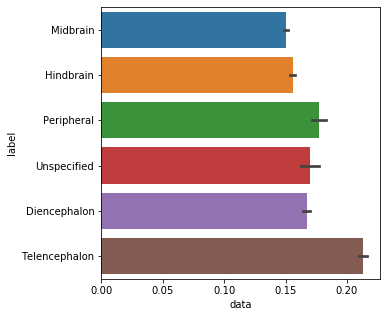

In [225]:
#Neurons pooled across fish
df, lab = cfn.ccm_region(data, coord, 'coarse')

#Visualise single dataset bar plot
fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(y="label", x="data", data=df)
plt.show()

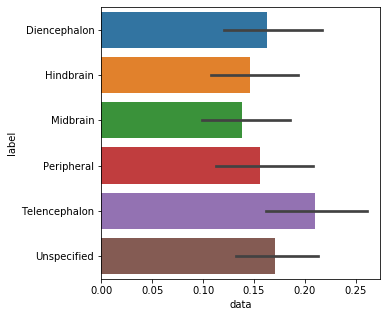

In [226]:
#Mean for each fish
mean_df, lab = cfn.ccm_region_mean(df)

#Visualise single dataset bar plot
fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(y="label", x="data", data=mean_df)
plt.show()

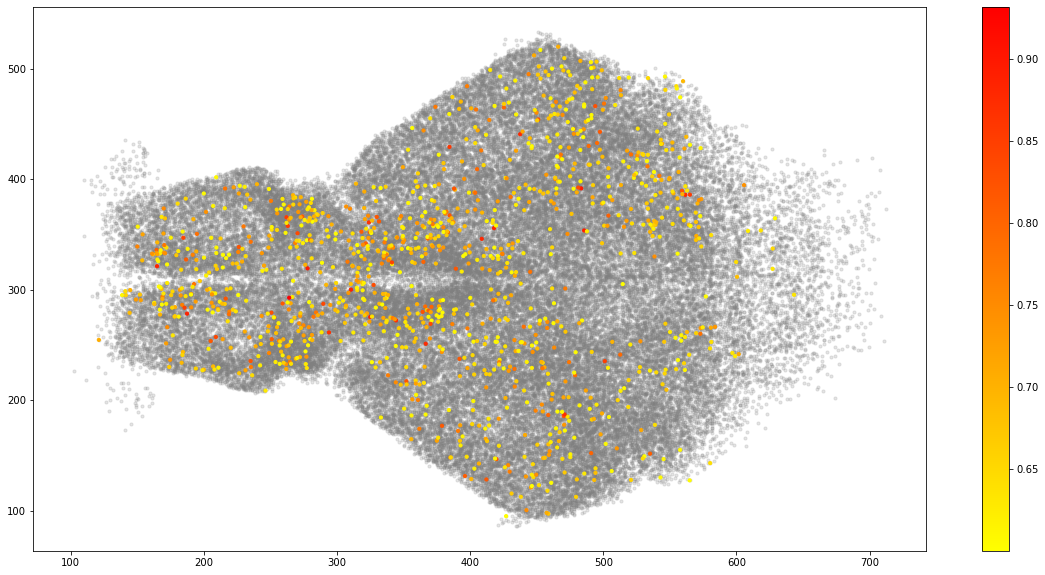

In [230]:
#Visualise fish
cfn.ccm_cellplot(df, 0.6, '', 0.5)

In [231]:
# CELLS DRIVEN BY FOCAL SEIZURE
cond_list = 'BLN', 'PTZ05', 'PTZ20'
cond = cond_list[1]
print(cond)

data_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + cond + '_run-01_t' + '*xmap*')
coord_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  cond + '_run' + '*1_pre-CCM.npy*')
data_l, coord_l

PTZ05


(['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-15_2photon_sess-01-6dpf_PTZ05_run-01_trace_CCMxmap.h5'],
 ['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-10_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-11_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ05_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-14_2p

In [232]:
#FOCAL SEIZURE
data, coord = cfn.ccm_cellstack(data_l, coord_l, 'sz_to_c')
data.shape, coord.shape

/Users/dominicburrows/Dropbox/PhD/Analysis/my_scripts/GitHub/empirical_dynamic_modelling/CCM.py:136: H5pyDeprecationWarning: The default file mode will change to 'r' (read-only) in h5py 3.0. To suppress this warning, pass the mode you need to h5py.File(), or set the global default h5.get_config().default_file_mode, or set the environment variable H5PY_DEFAULT_READONLY=1. Available modes are: 'r', 'r+', 'w', 'w-'/'x', 'a'. See the docs for details.
  data = h5py.File(file)


((89564,), (89564, 6))

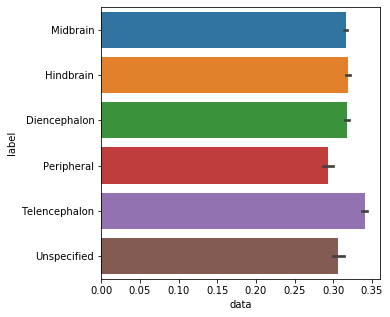

In [233]:
#Neurons pooled across fish
df, lab = cfn.ccm_region(data, coord, 'coarse')

#Visualise single dataset bar plot
fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(y="label", x="data", data=df)
plt.show()

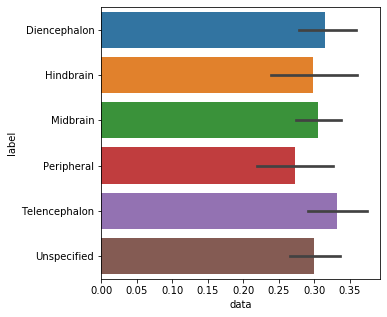

In [234]:
#Mean for each fish
mean_df, lab = cfn.ccm_region_mean(df)

#Visualise single dataset bar plot
fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(y="label", x="data", data=mean_df)
plt.show()

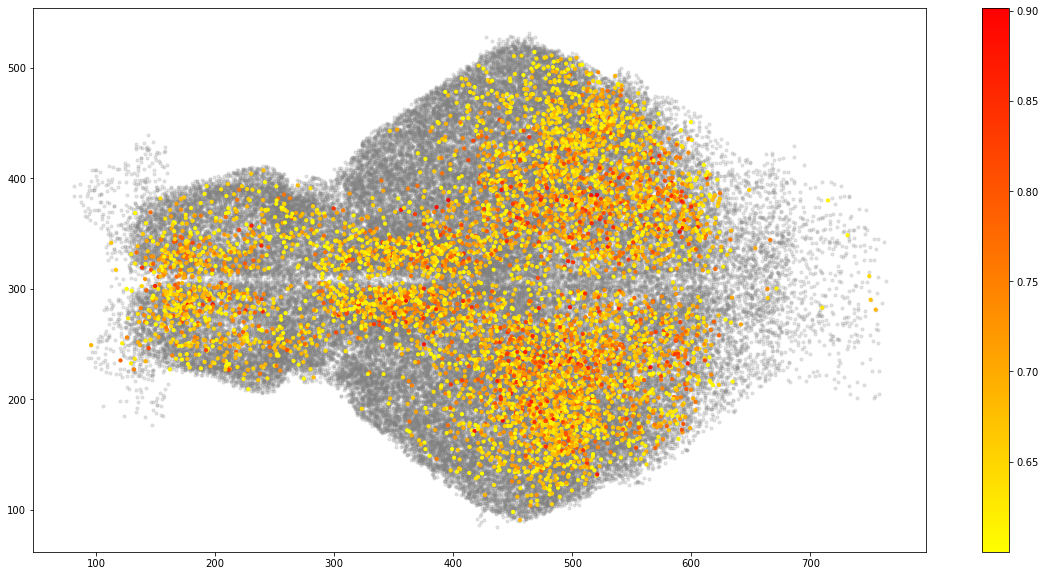

In [235]:
#Visualise fish
cfn.ccm_cellplot(df, 0.6, '', 0.5)

In [3]:
# CELLS DRIVEN BY GEN SEIZURE
cond_list = 'BLN', 'PTZ05', 'PTZ20'
cond = cond_list[2]
print(cond)

data_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' + cond + '_run-01_t' + '*xmap*')
coord_l = adfn.return_files(Fdata, 'PTZ-WILDTYPE-CCM', '*' +  cond + '_run' + '*1_pre-CCM.npy*')
data_l, coord_l

PTZ20


(['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ20_run-01_trace_CCMxmap.h5'],
 ['PTZ-WILDTYPE-03_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-06_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-07_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-13_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy',
  'PTZ-WILDTYPE-14_2photon_sess-01-6dpf_PTZ20_run-01_pre-CCM.npy'])

In [4]:
#GEN
data, coord = cfn.ccm_cellstack(data_l, coord_l, 'sz_to_c')
data.shape, coord.shape

/Users/dominicburrows/Dropbox/PhD/Analysis/my_scripts/GitHub/empirical_dynamic_modelling/CCM.py:136: H5pyDeprecationWarning: The default file mode will change to 'r' (read-only) in h5py 3.0. To suppress this warning, pass the mode you need to h5py.File(), or set the global default h5.get_config().default_file_mode, or set the environment variable H5PY_DEFAULT_READONLY=1. Available modes are: 'r', 'r+', 'w', 'w-'/'x', 'a'. See the docs for details.
  data = h5py.File(file)


((44389,), (44389, 6))

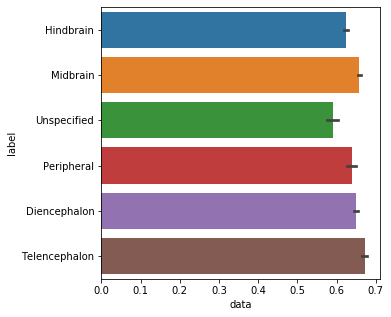

In [5]:
#Neurons pooled across fish
df, lab = cfn.ccm_region(data, coord, 'coarse')

#Visualise single dataset bar plot
fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(y="label", x="data", data=df)
plt.show()

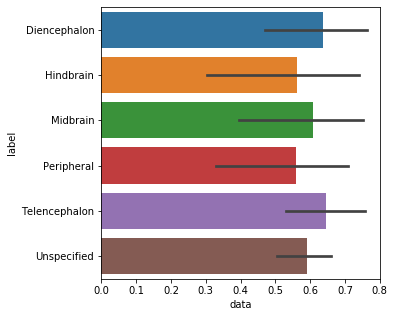

In [6]:
#Mean for each fish
mean_df, lab = cfn.ccm_region_mean(df)

#Visualise single dataset bar plot
fig, ax = plt.subplots(figsize = ((5,5)))
ax = sns.barplot(y="label", x="data", data=mean_df)
plt.show()

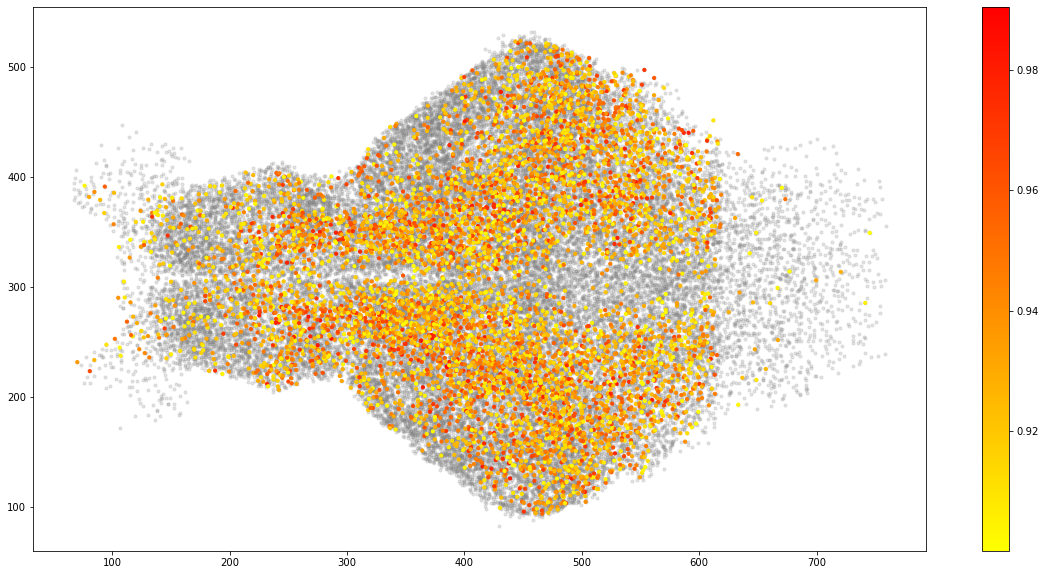

In [8]:
#Visualise fish
cfn.ccm_cellplot(df, 0.9, '', 0.5)